<style>
  .banner-trabajo {
    font-family: 'Georgia', 'Times New Roman', Times, serif;
    width: 80%;
    margin: 20px auto;
    padding: 10px 20px 20px 20px;
    background: #ffffff;
    border-left: 20px solid #003366;
    box-shadow: 0 5px 20px rgba(0,0,0,0.1);
    text-align: center;
    border-radius: 8px;
  }
  .banner-trabajo .encabezado {
    display: flex;
    align-items: center;
    justify-content: center;
    gap: 20px;
    margin-bottom: 15px;
    padding-bottom: 1px;
    border-bottom: 2px solid #eeeeee;
  }
  .banner-trabajo .logo-universidad {
    max-width: 80px;
    height: auto;
  }
  .banner-trabajo .universidad {
    font-size: 1.1em;
    color: #003366;
    font-weight: bold;
    text-align: left;
  }
  .banner-trabajo h1 {
    color: #003366;
    font-size: 2.2em;
    margin: 0.6em 0;
    font-weight: bold;
    line-height: 1.2;
  }
  .banner-trabajo h2 {
    color: #444444;
    font-size: 1.4em;
    margin-bottom: 0.8em;
    font-weight: normal;
    font-style: italic;
  }
  .banner-trabajo .info-autor {
    /* margin-top: 1em; */
    margin-bottom: 0em;
    font-size: 1.1em;
    color: #222222;
  }
  .banner-trabajo .fecha {
    margin: 1.0em 0 1.0em 0;
    padding: 0.8em 0;
    color: #666666;
    font-size: 1em;
  }
</style>

<div class="banner-trabajo">
  <div class="encabezado">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" class="logo-universidad">
    <div class="universidad"> Universidad Nacional de Colombia</div>
  </div>
  
  <h1>Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2>Análisis exploratorio de datos y entrenamiento de modelos de aprendizaje de máquinas con datos de fríjol</h2>
  
  <div class="info-autor">
    <p><strong>Autor:</strong> Selene Solano Vera</p>
    <!-- <p><strong>Asesor:</strong> </p> -->
  </div>
  
  <div class="fecha"> Medellín, Febrero de 2026</div>

  <div style="height: 0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias y la configuración del entorno de trabajo para el análisis exploratorio de datos y el entrenamiento de modelos de aprendizaje automático.

## Importar librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, ConfusionMatrixDisplay
import warnings
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import math
import os
import pickle
from datetime import datetime
import time

## Configurar estilo de visualización

In [ ]:
# Configuración del tema visual de seaborn
sns.set_theme(style="whitegrid", palette="viridis")

# Configuración de parámetros globales de matplotlib
plt.rcParams['figure.figsize'] = (12, 7)    # Tamaño de figura predeterminado (ancho, alto) en pulgadas
plt.rcParams['axes.titlesize'] = 18         # Tamaño de fuente para títulos de gráficos
plt.rcParams['axes.labelsize'] = 14         # Tamaño de fuente para etiquetas de ejes

# Suprimir advertencias para mantener limpia la salida del notebook
warnings.filterwarnings('ignore')

# 1. Definición del Problema y Recopilación de Datos

**Pregunta de Investigación:** ¿Es posible determinar el nivel de deficiencia de fósforo en plantas de fríjol mediante el análisis de la intensidad de reflectancia en imágenes multiespectrales?

**Hipótesis:** Las plantas con diferentes niveles de deficiencia de fósforo presentarán patrones distintivos en su reflectancia espectral que permitirán su clasificación automática.

**Descripción de los datos**

- Variable Objetivo:

    - Tratamiento 1: 25% de la dosis óptima de fósforo (deficiencia severa)
    - Tratamiento 2: 50% de la dosis óptima de fósforo (deficiencia moderada)
    - Tratamiento 3: 75% de la dosis óptima de fósforo (deficiencia leve)
    - Tratamiento 4: 100% de la dosis óptima de fósforo (control saludable)

- Variables Predictoras:

    - `pixel_relativo_x/y`: Coordenadas relativas al centroide de la planta
    - `intensidad`: Valor de reflectancia espectral
    - `genotipo`: Identificador del genotipo (1-8)
    - `banda`: Banda espectral de captura

**Fuente y recopilación de los datos**

Se cuenta con un conjunto de imágenes multiespectrales, las cuales fueron desagregadas por bandas para su posterior procesamiento. De cada banda se extrajeron los valores correspondientes a la intensidad y a los píxeles relativos. La definición de cada banda se encuentra asociada a la separación de los canales espectrales, cuyos valores están previamente determinados por el sensor de adquisición. Finalmente, la identificación del genotipo se realizó mediante la aplicación de una máscara sobre la imagen.

# 2. Carga y Primera Inspección de Datos

## 2.1. Leer datos de fríjol

Se cargan los datos preprocesados de imágenes multiespectrales de plantas de frijol. El dataset contiene información sobre píxeles extraídos de diferentes bandas espectrales, con sus respectivas coordenadas relativas e intensidades de reflectancia.

In [ ]:
# Carga del dataset desde archivo CSV
# Contiene datos de píxeles extraídos de imágenes multiespectrales de plantas de frijol
# con diferentes niveles de deficiencia de fósforo
data = pd.read_csv('datasets/dataset_frijol.csv')

## 2.2. Exploración inicial de los datos

Esta fase comprende un análisis preliminar del dataset para entender su estructura, identificar las variables disponibles, detectar valores faltantes o inconsistentes, y obtener estadísticas descriptivas básicas.

In [ ]:
# Visualización de las primeras filas del dataset
data.head()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
0,-14.8,-284.67,1,1,2,444
1,-13.8,-284.67,1,1,2,444
2,-14.8,-283.67,1,1,2,444
3,-13.8,-283.67,1,1,2,444
4,-12.8,-283.67,1,1,2,444


In [ ]:
# Visualización de las últimas filas del dataset
data.tail()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
3314445,17.54,238.46,24,8,4,848
3314446,18.54,238.46,25,8,4,848
3314447,19.54,238.46,26,8,4,848
3314448,18.54,239.46,24,8,4,848
3314449,19.54,239.46,24,8,4,848


**Dimensiones del dataset**

In [ ]:
# Dimensiones del dataset: (número de filas, número de columnas)
print(f"Tamaño del dataset: {data.shape}")

Tamaño del dataset: (3314450, 6)


In [ ]:
# Nombres de las columnas del dataset
print(f"Columnas:\n {data.columns}")

Columnas:
 Index(['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo',
       'tratamiento', 'banda'],
      dtype='object')


### Estadísticas descriptivas

Obtención de medidas de tendencia central (media, mediana) y dispersión (desviación estándar, cuartiles) para todas las variables numéricas del dataset.

In [ ]:
# Estadísticas descriptivas para todas las variables numéricas
data.describe()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
count,3.314450e+06,3.314450e+06,3.314450e+06,3.314450e+06,3.314450e+06,3.314450e+06
mean,4.055273e-04,2.634223e-04,7.824041e+00,4.562368e+00,2.404194e+00,6.338000e+02
std,1.286624e+01,1.828432e+02,7.687756e+00,2.266423e+00,1.149631e+00,1.215893e+02
min,-4.289000e+01,-3.865400e+02,0.000000e+00,1.000000e+00,1.000000e+00,4.440000e+02
25%,-8.680000e+00,-1.565500e+02,2.000000e+00,3.000000e+00,1.000000e+00,5.310000e+02
50%,-1.000000e-02,1.614000e+01,5.000000e+00,5.000000e+00,2.000000e+00,6.590000e+02
75%,8.590000e+00,1.609100e+02,1.200000e+01,6.000000e+00,3.000000e+00,7.170000e+02
max,5.233000e+01,3.821100e+02,3.900000e+01,8.000000e+00,4.000000e+00,8.480000e+02


**Análisis de rangos:**

- `Intensidad`: Media = 7.8, rango [0-39]
- `Pixel_rel_x`: Rango [-42, 52]
- `Pixel_rel_y`: Rango [-386, 390]

La gran diferencia en escalas entre variables (intensidad ~8 vs pixel_rel_y ~400) confirma la necesidad de normalización o estandarización para algoritmos de machine learning sensibles a escala (SVM, KNN, redes neuronales).

**Interpretación:** El valor promedio bajo de intensidad (7.8) es consistente con la reflectancia típica del tejido vegetal verde, que absorbe fuertemente la luz visible para la fotosíntesis. El máximo de 39, aunque relativamente bajo comparado con el rango teórico de 0-255, puede representar estructuras específicas como nervaduras o bordes foliares.

### Resumen de información del dataset

Muestra información detallada sobre el dataset incluyendo tipos de datos, uso de memoria y valores no nulos por columna.

In [ ]:
# Información general del dataset: tipos de datos, valores no nulos y uso de memoria
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3314450 entries, 0 to 3314449
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   pixel_relativo_x  float64
 1   pixel_relativo_y  float64
 2   intensidad        int64  
 3   genotipo          int64  
 4   tratamiento       int64  
 5   banda             int64  
dtypes: float64(2), int64(4)
memory usage: 151.7 MB


### Verificación de calidad de los datos

Se realiza una inspección para detectar valores nulos (missing values) y registros duplicados, los cuales pueden afectar la calidad del análisis y el rendimiento de los modelos.

In [ ]:
# Conteo de valores nulos por columna
data.isnull().sum()

pixel_relativo_x    0
pixel_relativo_y    0
intensidad          0
genotipo            0
tratamiento         0
banda               0
dtype: int64

In [ ]:
# Conteo de registros duplicados en el dataset
data.duplicated().sum()

np.int64(0)

**Características del dataset:**

- **Tamaño:** 3,314,450 registros × 6 variables
- **Tipo de datos:** Todos numéricos, sin necesidad de parsing o encoding
- **Calidad:** Sin valores nulos ni registros duplicados

# 3. Análisis Exploratorio de Datos (EDA)

- Comprender la estructura y distribución de las variables
- Identificar patrones, tendencias y anomalías
- Detectar relaciones entre variables
- Identificar necesidad de procesos de preprocesamiento y selección de modelos
- Generar hipótesis sobre los factores que influyen en la variable objetivo

In [ ]:
# Clasificación de variables según
# Variables numéricas continuas
columnas_numericas = ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad']

# Variables categóricas
columnas_categoricas = ['genotipo', 'banda', 'tratamiento']

## 3.1. Análisis univariado de variables

Se examina cada variable de forma individual para comprender su distribución, tendencia central, dispersión y valores atípicos.

### 3.1.1. Análisis de variables categóricas

In [ ]:
# Identificación de valores únicos en las variables categóricas
print("Valores únicos de las variables categóricas:\n")
for variable in columnas_categoricas:
    print(f"{variable}: {data[variable].unique()}")

Valores únicos de la variables categóricas:

genotipo: [1 2 3 4 5 6 7 8]
banda: [444 475 531 560 650 668 705 717 740 848]
tratamiento: [2 1 3 4]


**Distribución de las variables**

In [ ]:
# Conteo de frecuencias para la variable 'genotipo'
data['genotipo'].value_counts()

genotipo
5    444630
6    444090
4    436670
8    434430
3    400310
1    396940
7    379860
2    377520
Name: count, dtype: int64

In [ ]:
# Conteo de frecuencias para la variable objetivo 'tratamiento'
data['tratamiento'].value_counts()

tratamiento
1    970720
2    853790
4    820460
3    669480
Name: count, dtype: int64

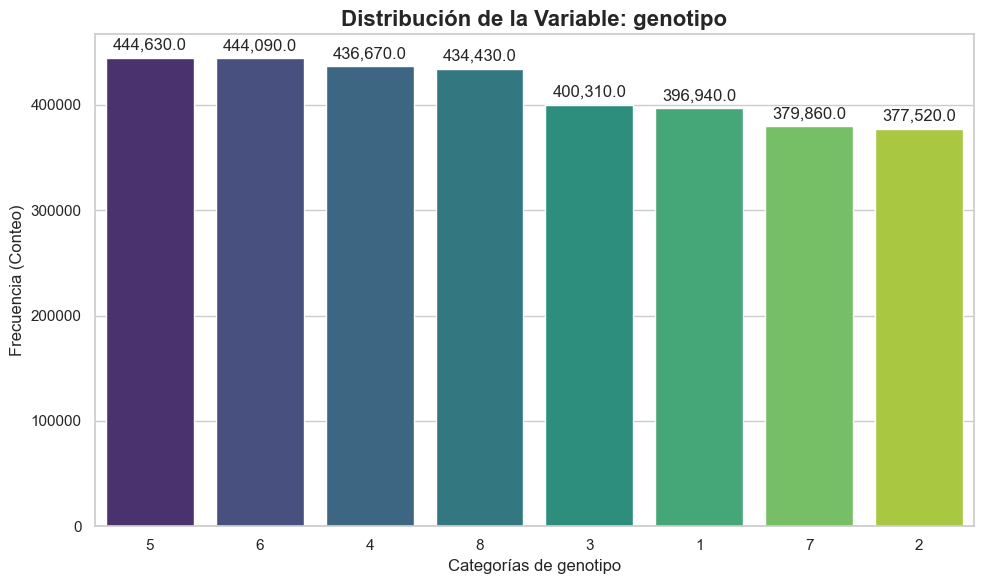

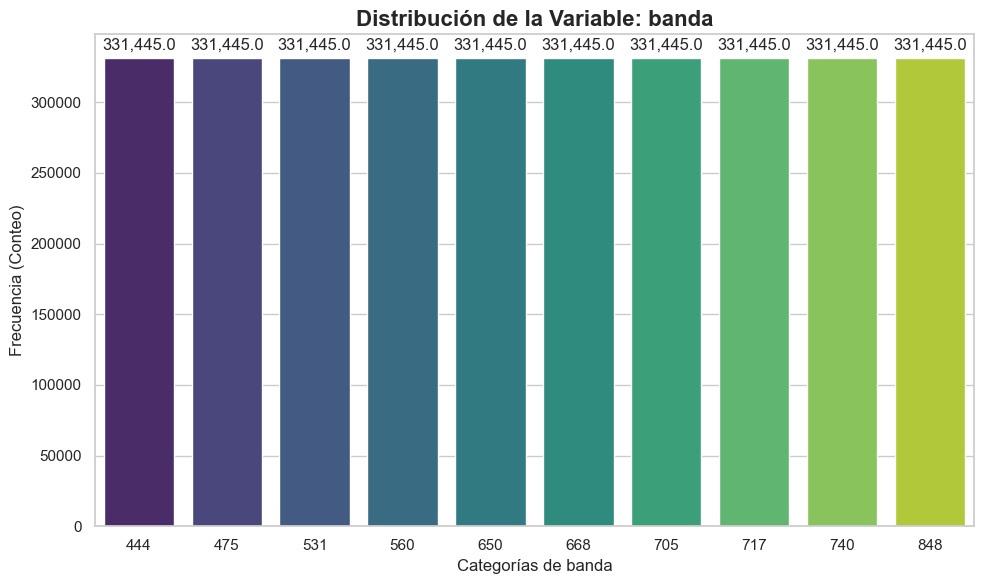

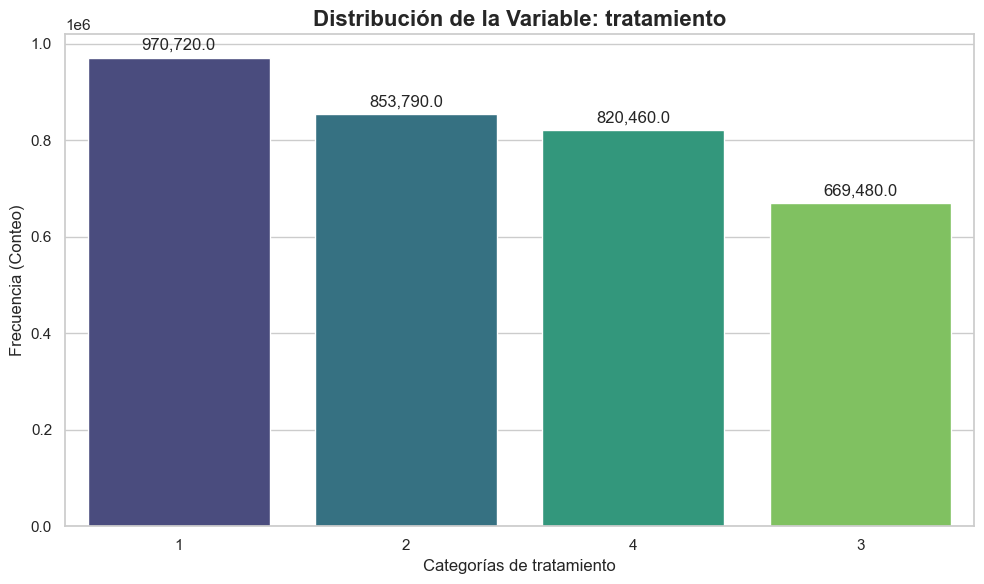

In [ ]:
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    
    # countplot de seaborn que cuenta automáticamente las frecuencias
    ax = sns.countplot(x=col, data=data, order=data[col].value_counts().index, palette='viridis')
    
    # Añadir título y etiquetas claras
    ax.set_title(f'Distribución de la Variable: {col}', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Categorías de {col}', fontsize=12)
    ax.set_ylabel('Frecuencia (Conteo)', fontsize=12)
    
    # Añadir anotaciones sobre cada barra para mayor claridad
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
        
    plt.tight_layout()
    plt.show()

**Interpretación:**

Distribución de frecuencias de las tres variables categóricas:

1. **Genotipo**: Presenta una distribución uniforme entre los 8 genotipos (1-8), con aproximadamente 400,000 muestras cada uno. Esta uniformidad indica un diseño experimental balanceado que garantiza representatividad de la diversidad genética.

2. **Banda**: Muestra 10 bandas espectrales diferentes con frecuencias similares (~331,000 muestras cada una), lo que refleja el mismo número de píxeles capturados por cada filtro espectral del sensor multiespectral.

3. **Tratamiento**: Aunque relativamente balanceado, existe una ligera variación entre tratamientos. El T1 (deficiencia severa) tiene la mayor representación con ~970,720 muestras, mientras que T3 (deficiencia leve) tiene la menor con ~669,480 muestras. Esta diferencia del 18.3% es manejable pero puede considerarse la aplicación de técnicas de balanceo.

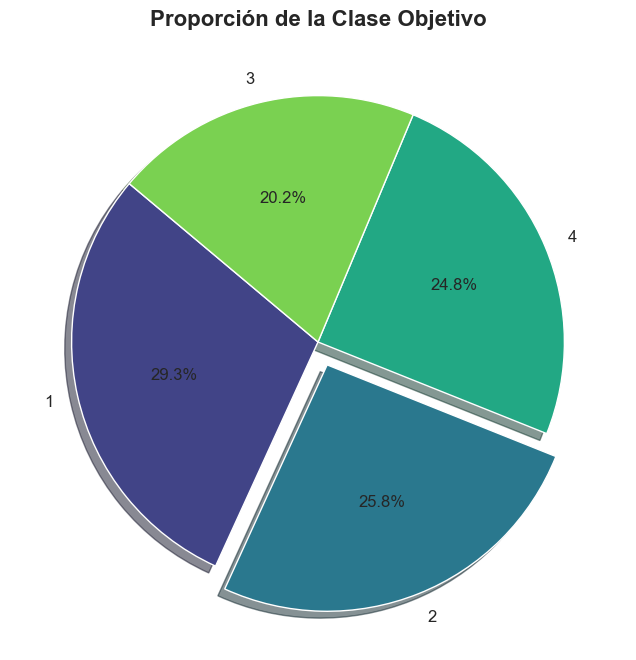

In [17]:
# Contar las frecuencias
counts = data['tratamiento'].value_counts()

colors = sns.color_palette('viridis', len(counts))
explode = [0.1 if i == counts.idxmax() else 0 for i, _ in enumerate(counts)]

plt.figure(figsize=(8, 8))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', # Formato de porcentaje
        startangle=140, 
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Proporción de la Clase Objetivo', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

**Interpretación del gráfico de torta:**

Proporción de cada tratamiento en el dataset:

- **T1 (29.3%)**: Plantas con 25% de fósforo (deficiencia severa) - Mayor representación
- **T2 (25.8%)**: Plantas con 50% de fósforo (deficiencia moderada)
- **T4 (24.8%)**: Plantas con 100% de fósforo (control saludable)
- **T3 (20.2%)**: Plantas con 75% de fósforo (deficiencia leve) - Menor representación

El desbalance es moderado (diferencia de 9.3 puntos porcentuales entre extremos), lo que no debería afectar significativamente el rendimiento del modelo. Sin embargo, es importante monitorear que el modelo no desarrolle un sesgo hacia la clasificación de T1.

**Distribución por Genotipo**

Distribución prácticamente uniforme entre genotipos, con diferencias promedio de ~50K registros entre el mayor y menor representado.

Esta uniformidad es metodológicamente favorable porque:

- Garantiza representatividad de la diversidad genética
- Evita sesgos hacia genotipos específicos
- Permite generalización robusta del modelo
- Con >400K muestras por genotipo, las diferencias no son estadísticamente significativas


**Distribución por Tratamiento (Variable Objetivo)**

- **Desbalance moderado:** Diferencia de 9.3 puntos porcentuales entre extremos. Mayor representación de plantas con deficiencia severa (T1) vs deficiencias leves (T3). Puede existir un riesgo de sesgo hacia clasificación de plantas con deficiencia severa.

Se pueden considerar técnicas de balanceo.

### 3.1.2 Variables numéricas

**Distribución de las variables y valores atípicos**

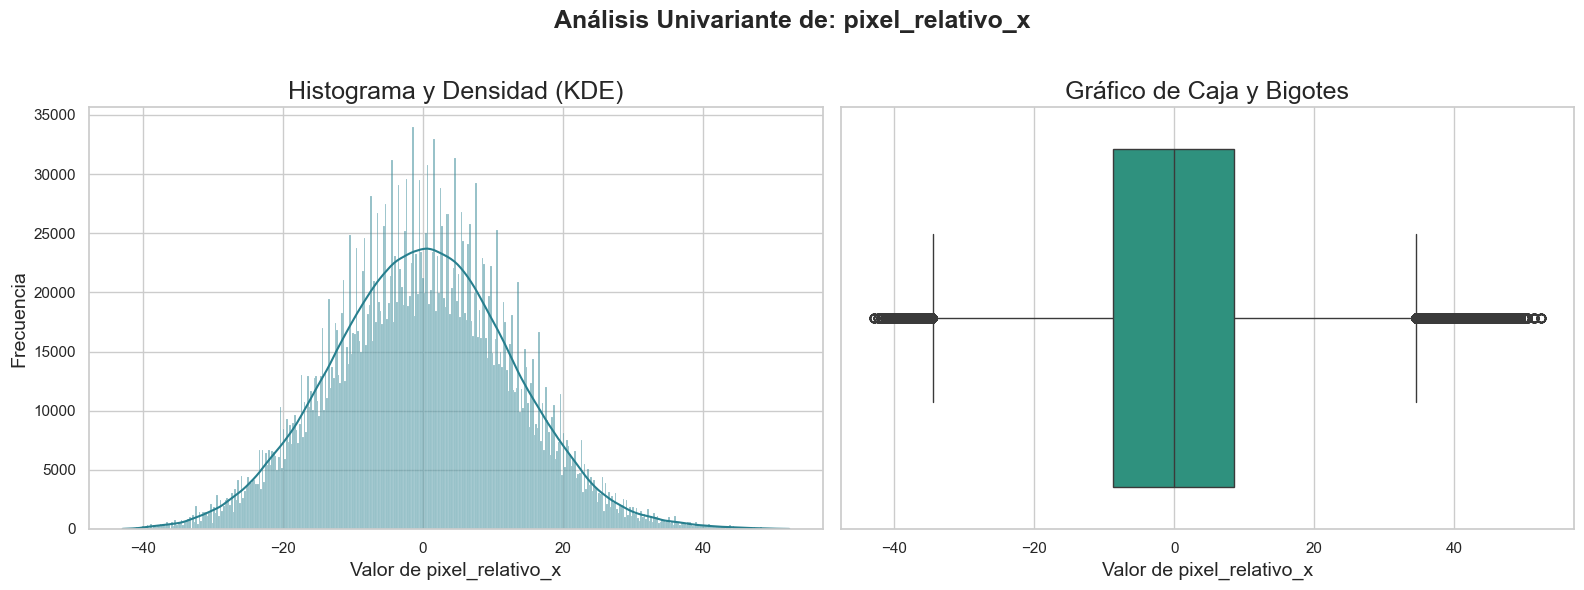

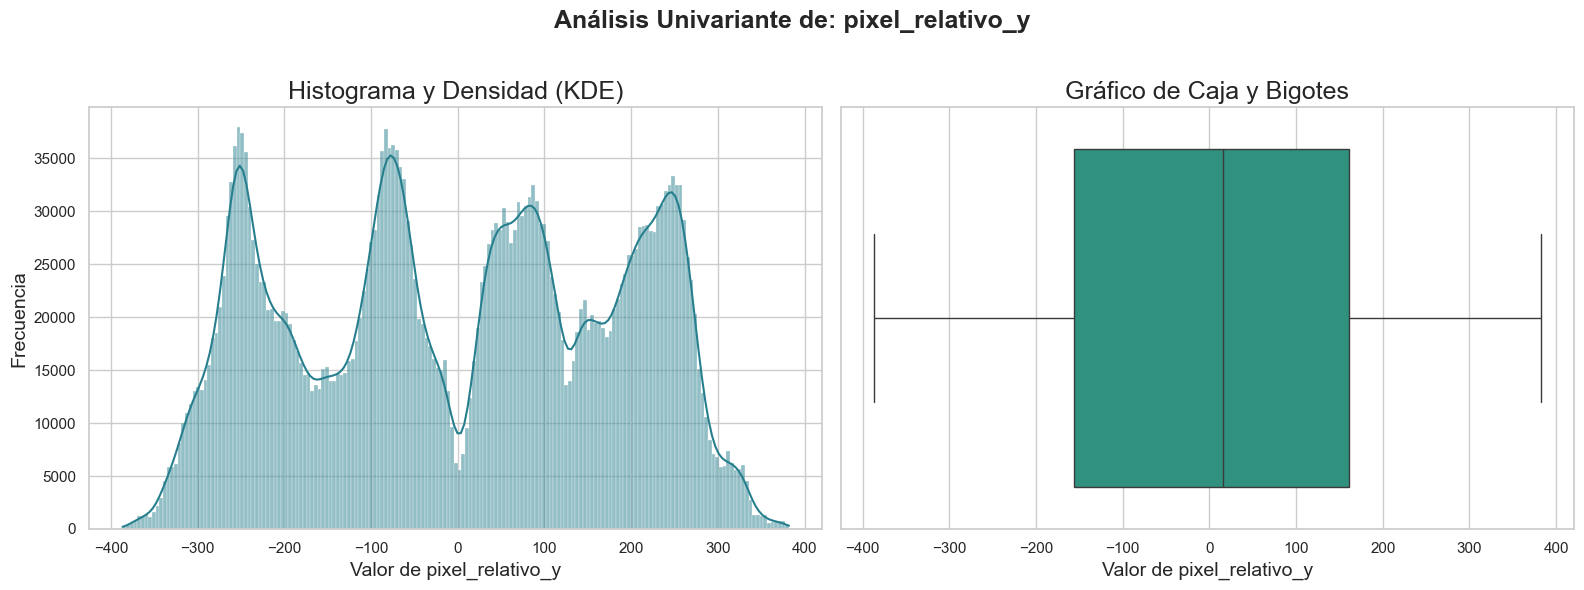

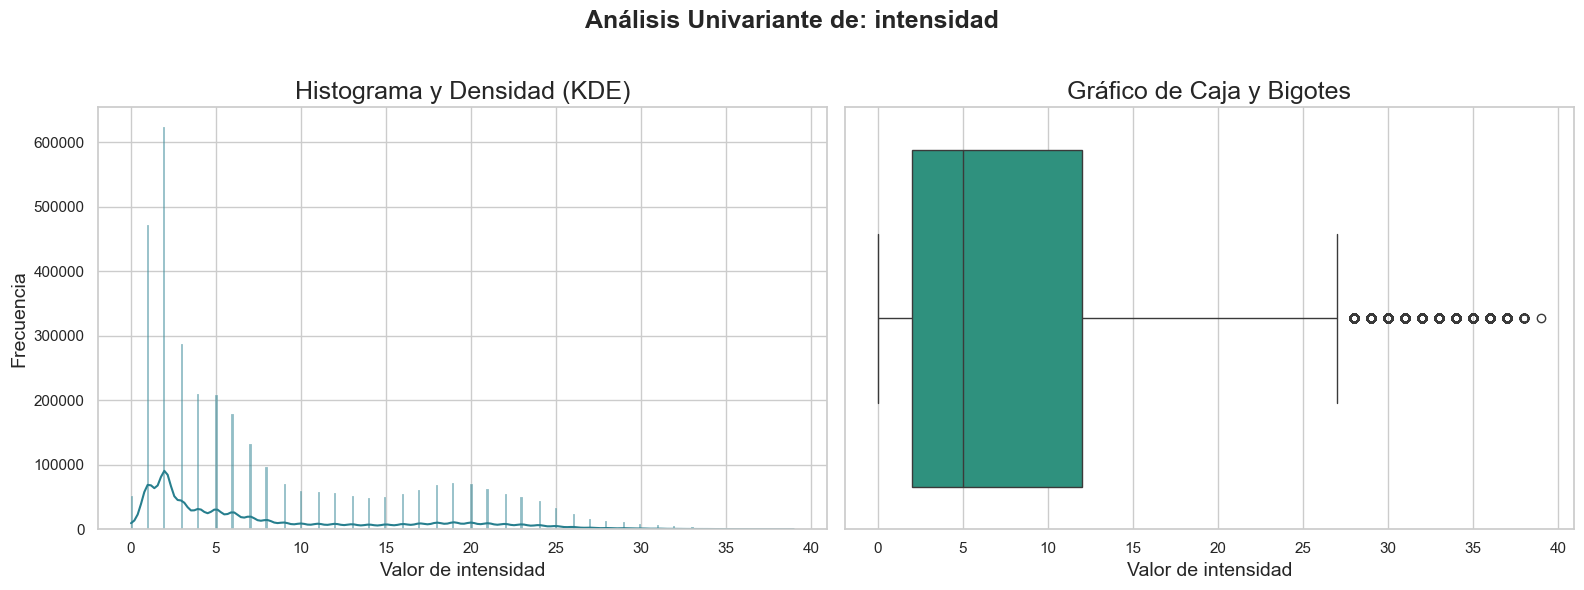

In [18]:
for col in columnas_numericas:
    # Crear una figura con dos subplots (uno al lado del otro)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Título general para la figura
    fig.suptitle(f'Análisis Univariante de: {col}', fontsize=18, fontweight='bold')
    
    # Histograma con KDE (Kernel Density Estimate)
    sns.histplot(data[col], kde=True, ax=axes[0], color=sns.color_palette('viridis')[2])
    axes[0].set_title('Histograma y Densidad (KDE)')
    axes[0].set_xlabel(f'Valor de {col}')
    axes[0].set_ylabel('Frecuencia')
    
    # Gráfico de Caja y Bigotes (Box Plot)
    sns.boxplot(x=data[col], ax=axes[1], color=sns.color_palette('viridis')[3])
    axes[1].set_title('Gráfico de Caja y Bigotes')
    axes[1].set_xlabel(f'Valor de {col}')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para que el suptitle no se superponga
    plt.show()


**Interpretación de histogramas y boxplots:**

**Pixel Relativo X:**
- *Histograma*: Distribución normal perfecta centrada en 0, indicando simetría bilateral de las hojas
- *Boxplot*: Mediana en 0, IQR simétrico (-10 a 10), bigotes hasta ±35
- *Interpretación*: Refleja la geometría natural de las hojas y confirma un centroide bien calculado

**Pixel Relativo Y:**
- *Histograma*: Distribución multimodal con 4 picos distintos entre -400 y 400
- *Boxplot*: Mediana ~15, IQR amplio (-175 a 175), sin outliers extremos
- *Interpretación*: Los picos múltiples sugieren estructura foliar compleja (ápice, base, márgenes) que podría ser informativa para distinguir tratamientos

**Intensidad:**
- *Histograma*: Fuertemente sesgado a la derecha, con ~1M de muestras en intensidad ≈1
- *Boxplot*: Mediana ~2, IQR estrecho (1-4), outliers hasta 34
- *Interpretación*: Distribución típica de reflectancia vegetal donde la mayoría del tejido presenta baja reflectancia (absorción de luz para fotosíntesis). Los valores altos probablemente corresponden a estructuras especializadas como nervaduras o bordes foliares.

## 3.2 Análisis de variables múltiples

### 3.2.1 Numérica vs. Numérica

#### Gráfico de dispersión

In [19]:
selected_data = data[["pixel_relativo_x","pixel_relativo_y","intensidad", "tratamiento"]]
sample_data = selected_data.sample(n=2000, random_state=42)

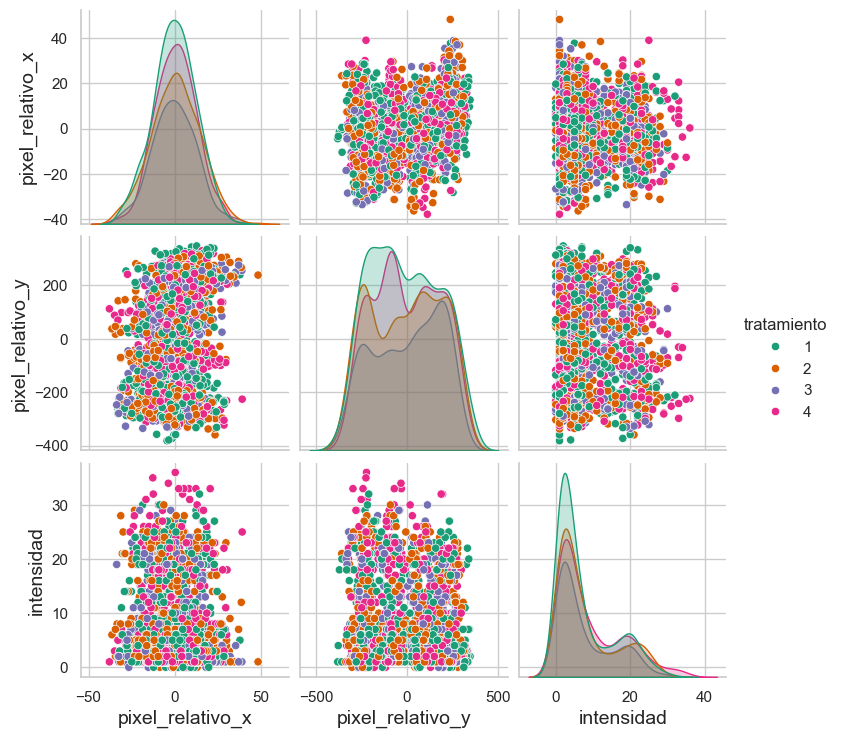

In [20]:
sns.pairplot(sample_data,hue='tratamiento',palette='Dark2')

**Interpretación del pairplot:**

1. **Ausencia de separación clara**: Los cuatro tratamientos se superponen considerablemente en todas las combinaciones de variables, lo que indica que la clasificación no es trivial y requerirá modelos sofisticados.

2. **Distribuciones marginales**: Los histogramas en la diagonal confirman los patrones individuales (normal para pixel_x, multimodal para pixel_y, sesgada para intensidad).

3. **Independencia espacial-espectral**: No se observan patrones claros de correlación entre posición espacial (x, y) e intensidad, sugiriendo que la reflectancia es relativamente homogénea a través de la hoja.

4. **Desafío de clasificación**: La superposición considerable entre tratamientos implica que el modelo deberá aprender patrones sutiles y multidimensionales para discriminar efectivamente entre niveles de deficiencia de fósforo.

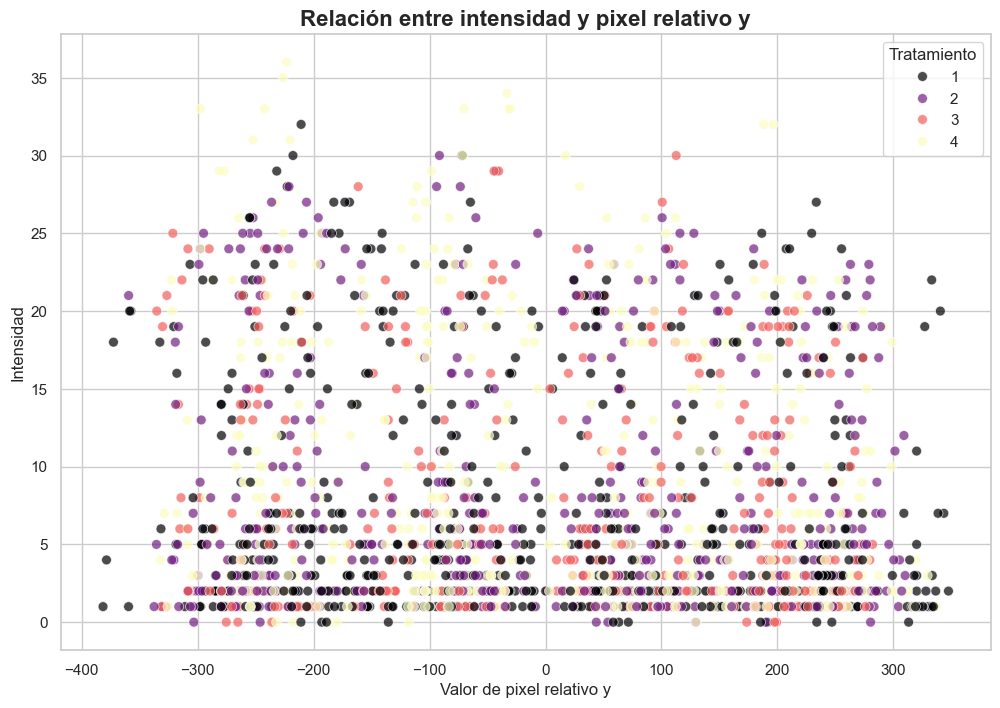

In [21]:
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=sample_data, 
    x='pixel_relativo_y', 
    y='intensidad', 
    hue='tratamiento', # Clave para el análisis multivariable
    palette='magma',      # Una paleta diferente para variar
    alpha=0.7,            # Transparencia para ver superposiciones
    s=50                  # Tamaño de los puntos
)

ax.set_title('Relación entre intensidad y pixel relativo y', fontsize=16, fontweight='bold')
ax.set_xlabel('Valor de pixel relativo y', fontsize=12)
ax.set_ylabel('Intensidad', fontsize=12)
plt.legend(title='Tratamiento')
plt.show()

**Interpretación del scatter plot (Intensidad vs Pixel Relativo Y):**

1. **Distribución aleatoria**: No hay relación lineal aparente entre la posición Y y la intensidad, lo que sugiere homogeneidad fisiológica del tejido fotosintético.

2. **Concentración en valores bajos**: La mayoría de los puntos se concentran en intensidades 1-5, independientemente de su posición vertical en la hoja.

3. **Superposición de tratamientos**: Los cuatro tratamientos están completamente mezclados, confirmando que la diferenciación no se puede lograr con variables individuales.

4. **Implicación biológica**: La ausencia de gradientes de intensidad a lo largo del eje Y sugiere que la absorción de fósforo afecta uniformemente todo el tejido foliar, en lugar de crear patrones espaciales distintivos.

Este hallazgo refuerza la necesidad de utilizar todas las características simultáneamente y considerar interacciones complejas entre bandas espectrales, posición y genotipo.

#### Matriz de correlaciones

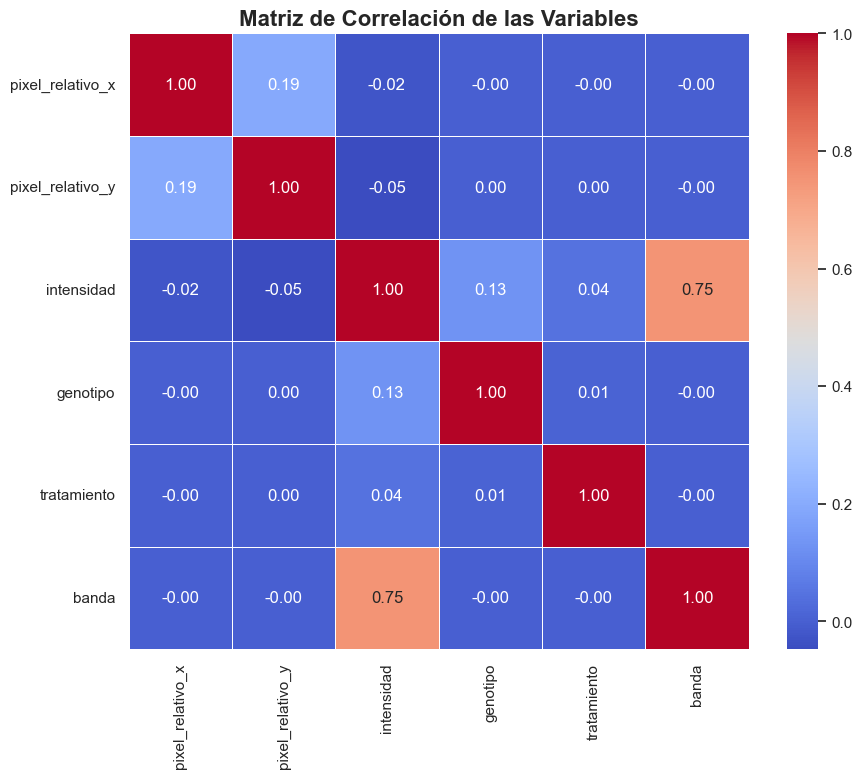

In [22]:
corr_matrix = data.corr()

plt.figure(figsize=(10, 8))

# Usamos un mapa de calor para visualizar la matriz
sns.heatmap(
    corr_matrix, 
    annot=True,       # Muestra los valores de correlación en las celdas
    cmap='coolwarm',  # Paleta de colores ideal para correlaciones (-1: azul, 0: blanco, 1: rojo)
    fmt=".2f",        # Formato de los números a dos decimales
    linewidths=.5
)

plt.title('Matriz de Correlación de las Variables', fontsize=16, fontweight='bold')
plt.show()

**Interpretación de la matriz de correlación:**

Correlaciones de Pearson entre todas las variables numéricas:

1. **Intensidad-Banda (r = 0.75)**: Correlación fuerte positiva esperada, ya que diferentes bandas espectrales capturan diferentes niveles de reflectancia según las propiedades de absorción del tejido vegetal. Esta alta correlación confirma la coherencia espectral del sistema de captura.

2. **Variables espaciales (r ≈ 0.05)**: Pixel X y Y muestran correlación prácticamente nula, confirmando que son dimensiones independientes del espacio de la hoja.

3. **Espacial-Espectral (r < 0.1)**: Las correlaciones muy bajas entre coordenadas espaciales (X, Y) e intensidad confirman la ausencia de gradientes espaciales en la reflectancia.

4. **Intensidad-Tratamiento (r = 0.02)**: Correlación débil que explica la dificultad de clasificación observada en los scatter plots. Los tratamientos no se distinguen fácilmente por intensidad promedio.

**Implicaciones para el modelo:**
- Baja multicolinealidad: Todas las variables aportan información única
- No es necesario eliminar variables redundantes
- La baja correlación con el target sugiere que se necesitarán modelos no lineales para capturar relaciones complejas

### 3.2.2 Numérica vs. Categórica

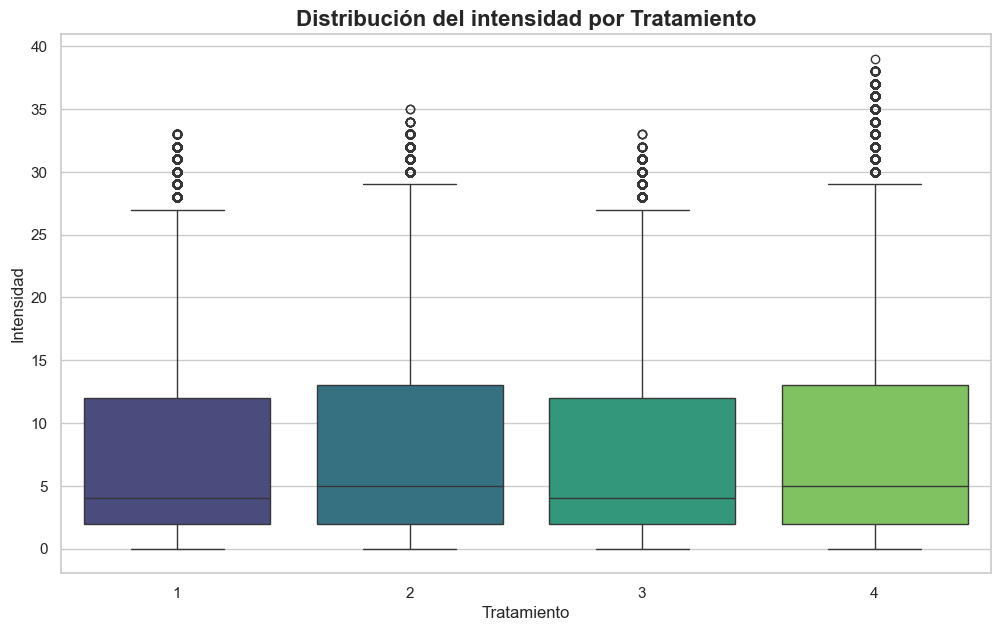

In [23]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=data,
    x='tratamiento',
    y='intensidad',
    palette='viridis'
)
plt.title('Distribución del intensidad por Tratamiento', fontsize=16, fontweight='bold')
plt.xlabel('Tratamiento', fontsize=12)
plt.ylabel('Intensidad', fontsize=12)
plt.show()

**Interpretación del boxplot (Intensidad por Tratamiento):**

Distribución de intensidad entre los cuatro tratamientos:

1. **Medianas similares**: T1 y T3 tienen mediana ~4, mientras que T2 y T4 tienen mediana ~5. Las diferencias son sutiles (solo 1 unidad).

2. **Distribuciones superpuestas**: Todos los tratamientos comparten el mismo límite inferior (0) y comienzan en ~2 (Q1), con considerable superposición de rangos intercuartílicos.

3. **Variabilidad**: T2 y T4 muestran mayor dispersión (IQR más amplio, ~2-17) comparado con T1 y T3 (IQR ~2-12).

4. **Outliers consistentes**: Todos los tratamientos presentan valores atípicos hasta ~35-39, representando estructuras con mayor reflectancia (nervaduras, bordes).

**Implicaciones:**
- La superposición considerable explica por qué la intensidad promedio por sí sola no es suficiente para clasificar tratamientos
- Las diferencias sutiles requieren que el modelo considere patrones espectrales multidimensionales
- Los outliers no deben eliminarse, ya que pueden contener información biológica relevante sobre estructuras foliares especializadas

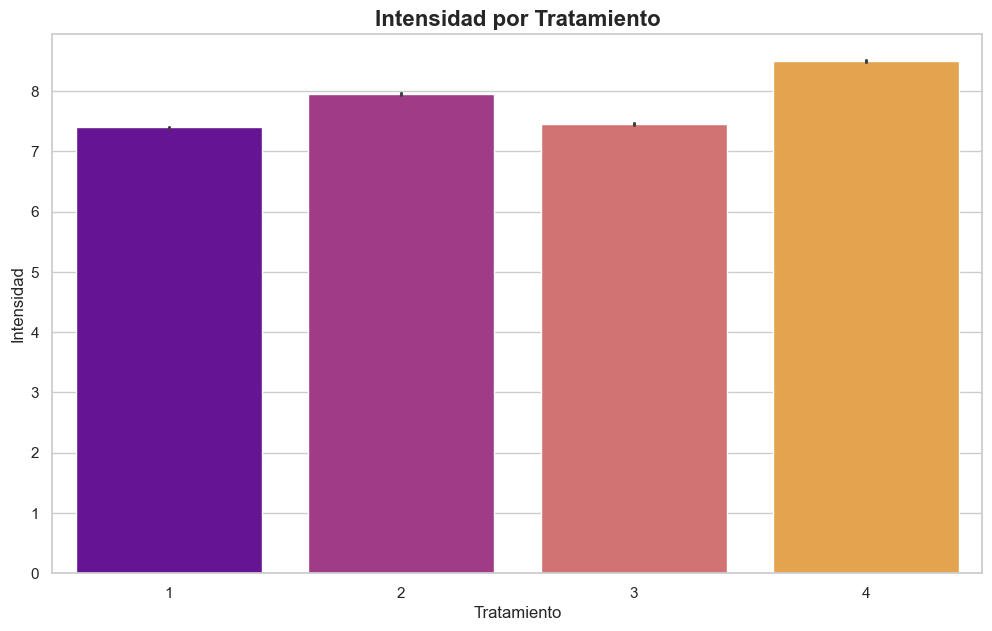

In [24]:
plt.figure(figsize=(12, 7))

# Las líneas negras son los intervalos de confianza
ax = sns.barplot(
    data=data,
    x='tratamiento',
    y='intensidad',
    palette='plasma'
)

ax.set_title('Intensidad por Tratamiento', fontsize=16, fontweight='bold')
ax.set_xlabel('Tratamiento', fontsize=12)
ax.set_ylabel('Intensidad', fontsize=12)
plt.show()

**Interpretación del gráfico de barras (Intensidad media por Tratamiento):**

Intensidad promedio para cada tratamiento con sus intervalos de confianza:

1. **Rango estrecho**: Las medias varían solo entre 7.5 y 8.5 (diferencia de 1.0 unidad), lo que representa una variación mínima considerando que los valores son enteros.

2. **Patrón no monotónico**: 
   - T1 (25% P): media = 7.5
   - T2 (50% P): media = 8.0
   - T3 (75% P): media = 7.5
   - T4 (100% P): media = 8.5

3. **Respuesta no lineal**: T1 y T3 tienen la misma media (7.5), sugiriendo una respuesta no lineal del estrés por fósforo en la reflectancia. Esto indica posibles umbrales fisiológicos en la respuesta de la planta.

4. **Intervalos de confianza**: Las barras negras (intervalos de confianza) se superponen considerablemente, indicando que las diferencias entre medias no son estadísticamente significativas con alta confianza.

El gráfico confirma que la clasificación basada únicamente en la intensidad promedio es inadecuada. El modelo debe explorar interacciones entre bandas espectrales, posición espacial y genotipo para detectar patrones más sutiles asociados con la deficiencia de fósforo.

### 3.2.3 Categórica vs. Categórica

In [25]:
contingency_table = pd.crosstab(data['genotipo'], data['tratamiento'])

print("Tabla de Contingencia (Frecuencias Absolutas):")
print(contingency_table)

contingency_table_percent = pd.crosstab(data['genotipo'], data['tratamiento'], normalize='index') * 100

print("\nTabla de Contingencia (Porcentajes por Fila - Genotipo):")
print(contingency_table_percent.round(2))

Tabla de Contingencia (Frecuencias Absolutas):
tratamiento       1       2      3       4
genotipo                                  
1            115410  109670  69510  102350
2            102290   91840  91210   92180
3            121280  103730  82870   92430
4            118200  129210  97510   91750
5            132620  125910  86060  100040
6            130940  114470  81280  117400
7            121690   69940  85040  103190
8            128290  109020  76000  121120

Tabla de Contingencia (Porcentajes por Fila - Genotipo):
tratamiento      1      2      3      4
genotipo                               
1            29.07  27.63  17.51  25.78
2            27.10  24.33  24.16  24.42
3            30.30  25.91  20.70  23.09
4            27.07  29.59  22.33  21.01
5            29.83  28.32  19.36  22.50
6            29.49  25.78  18.30  26.44
7            32.04  18.41  22.39  27.17
8            29.53  25.09  17.49  27.88


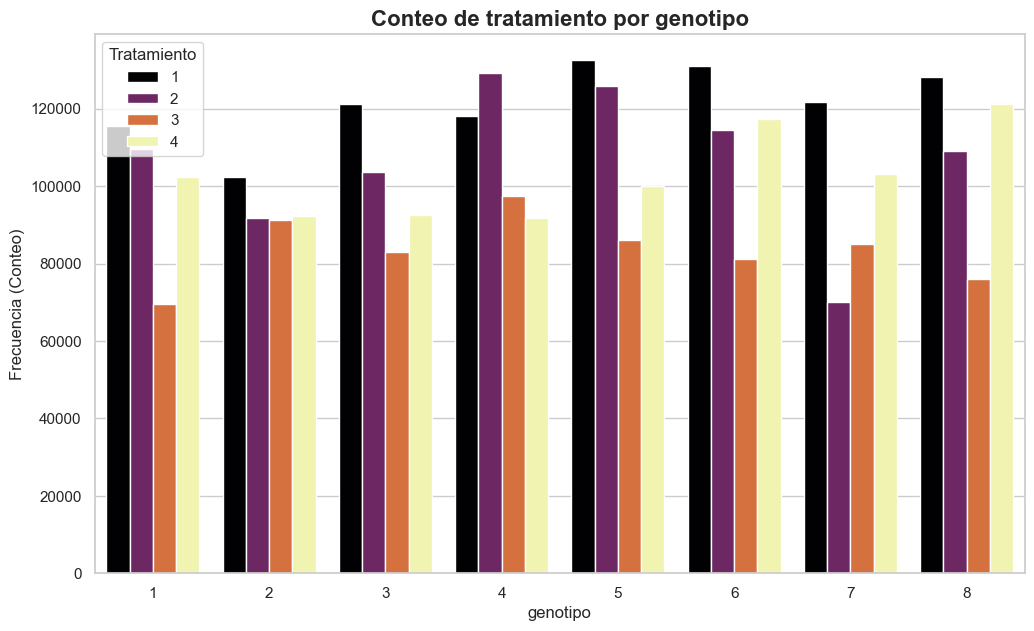

In [26]:
plt.figure(figsize=(12, 7))
sns.countplot(data=data, x='genotipo', hue='tratamiento', palette='inferno')
plt.title('Conteo de tratamiento por genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Frecuencia (Conteo)', fontsize=12)
plt.legend(title='Tratamiento')
plt.show()

**Interpretación del countplot (Tratamiento por Genotipo):**

Distribución de tratamientos dentro de cada genotipo:

1. **Distribución balanceada**: Cada genotipo contiene representación de los cuatro tratamientos, con barras de altura similar dentro de cada grupo.

2. **Consistencia entre genotipos**: Los patrones son similares a través de los 8 genotipos, sin concentraciones extremas o ausencias de combinaciones genotipo-tratamiento.

3. **Diseño experimental robusto**: El conteo relativamente uniforme confirma que el experimento fue diseñado para cruzar completamente genotipos con tratamientos.

**Implicaciones:**
- Sin sesgos genotipo-específicos que puedan confundir el modelo
- El modelo podrá aprender efectos del tratamiento independientes del genotipo
- Suficientes observaciones por combinación para entrenamiento robusto
- Capacidad de generalización a nuevos genotipos

#### Gráfico de Barras apiladas al 100%

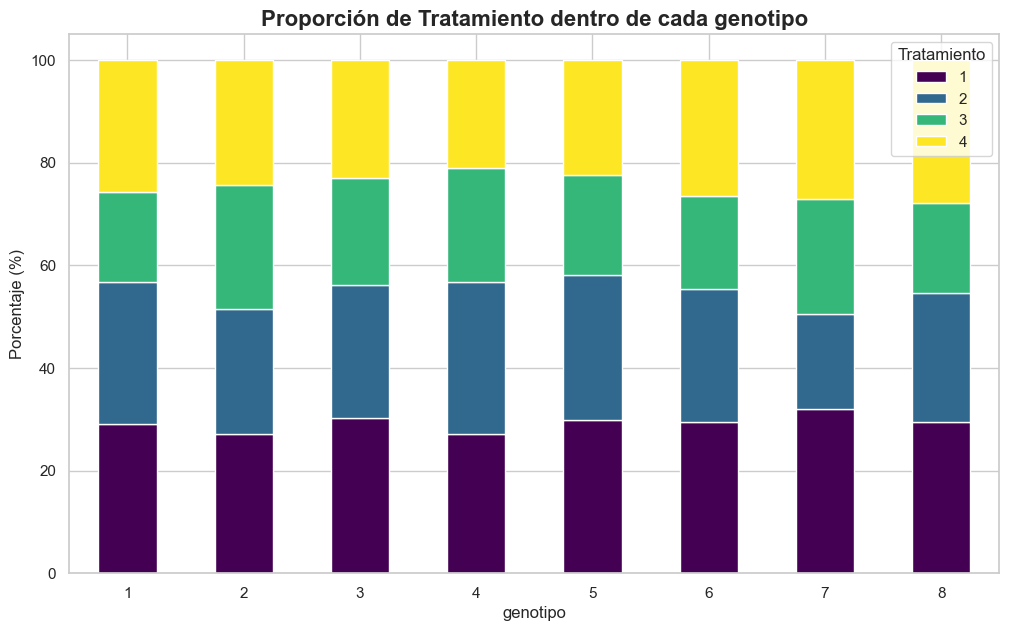

In [27]:
contingency_table_percent.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    colormap='viridis'
)
plt.title('Proporción de Tratamiento dentro de cada genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Tratamiento')
plt.xticks(rotation=0)
plt.show()

**Interpretación del gráfico de barras apiladas al 100%:**

Proporción de cada tratamiento dentro de cada genotipo, normalizando a 100%:

1. **Uniformidad proporcional**: Cada tratamiento representa aproximadamente 25% de cada genotipo, con variaciones menores (rango: 17.5% - 32.0%).

2. **Ausencia de patrones sistemáticos**: No hay genotipos que favorezcan o excluyan tratamientos específicos, confirmando aleatorización exitosa.

3. **Representatividad garantizada**: La distribución uniforme asegura que cada combinación genotipo-tratamiento tiene suficientes datos para entrenamiento.

Esta distribución equilibrada es fundamental para construir un modelo que distinga genuinamente los efectos del estrés por fósforo, independientemente del fondo genético.

## 3.3 Identificación sisemática de outliers

In [28]:
def identificar_outliers_iqr(dataframe, columna):
    """Identifica outliers en una columna usando el método del IQR."""
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    
    print(f"Outliers para '{columna}' usando el método IQR:")
    print(f"Límites: Inferior < {limite_inferior:.2f}, Superior > {limite_superior:.2f}")
    print(f"Número de outliers encontrados: {len(outliers)}")
    if len(outliers) > 0 and len(outliers) < 15: # Mostrar solo si son pocos
        print("Muestra de outliers:")
        print(outliers)
    return outliers


outliers_intensidad = identificar_outliers_iqr(data, 'intensidad')


def identificar_outliers_std(dataframe, columna, z_score_threshold=3):
    """Identifica outliers usando el Z-score (desviaciones estándar de la media)."""
    media = dataframe[columna].mean()
    std = dataframe[columna].std()
    
    limite_superior = media + z_score_threshold * std
    limite_inferior = media - z_score_threshold * std
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]

    print(f"\nOutliers para '{columna}' usando Desviación Estándar (Z-score > {z_score_threshold}):")
    print(f"Límites: Inferior < {limite_inferior:.2f}, Superior > {limite_superior:.2f}")
    print(f"Número de outliers encontrados: {len(outliers)}")
    if len(outliers) > 0 and len(outliers) < 15: 
        print("Muestra de outliers:")
        print(outliers)
    return outliers

outliers_sensor = identificar_outliers_std(data, 'intensidad')

Outliers para 'intensidad' usando el método IQR:
Límites: Inferior < -13.00, Superior > 27.00
Número de outliers encontrados: 50657

Outliers para 'intensidad' usando Desviación Estándar (Z-score > 3):
Límites: Inferior < -15.24, Superior > 30.89
Número de outliers encontrados: 19174


Valores de intensidad > 27-30:

- Posibles causas biológicas:

    - Nervaduras principales con mayor reflectancia
    - Bordes foliares con diferente estructura anatómica
    - Estructuras superficiales especializadas
    - Regiones senescentes con menor contenido de clorofila

No eliminar outliers - pueden contener información biológica relevante

# 4. Preprocesamiento de Datos

## 4.1. División de datos en conjuntos de entrenamiento y prueba

In [ ]:
# Separación de características (X) y variable objetivo (y)
X = data.drop('tratamiento', axis=1).copy()

# Vector de la variable objetivo (tratamiento con diferentes niveles de deficiencia de fósforo)
y = data['tratamiento'].copy()

In [ ]:
# División estratificada del dataset en conjuntos de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## 4.2. Normalización de características

La normalización mediante MinMaxScaler transforma las características al rango [0, 1], preservando las relaciones entre valores.

In [ ]:
# Inicialización y aplicación del escalador MinMaxScaler
scaler = MinMaxScaler() 

# Ajuste del escalador con datos de entrenamiento y transformación
X_train_scaled = scaler.fit_transform(X_train) 

# Transformación del conjunto de prueba usando los mismos parámetros
X_test_scaled = scaler.transform(X_test)

## 4.3. Codificación de tratamiento

Algoritmos de aprendizaje automático (como XGBoost) requieren que las etiquetas de clase sean enteros consecutivos comenzando desde 0. LabelEncoder realiza esta transformación automáticamente.

**XGBoost**

In [ ]:
# Inicialización y aplicación del codificador de etiquetas
le = LabelEncoder()

# Codificación de las etiquetas de entrenamiento: [1, 2, 3, 4] → [0, 1, 2, 3]
y_train_encoded = le.fit_transform(y_train)

# Codificación de las etiquetas de prueba usando el mismo mapeo
y_test_encoded = le.transform(y_test)

## 4.5. Persistencia de datos procesados

In [ ]:
# Almacenamiento de todos los conjuntos de datos procesados en formato comprimido .npz
np.savez("results/data/train_data_frijol.npz", 
         X_train_scaled=X_train_scaled, 
         X_test_scaled=X_test_scaled, 
         y_train=y_train,
         y_test=y_test,
         y_train_encoded=y_train_encoded, 
         y_test_encoded=y_test_encoded)

## 4.6. Carga de datos preprocesados

In [ ]:
# Carga del archivo .npz con todos los conjuntos de datos procesados
train_data = np.load("results/data/train_data_frijol.npz")

X_train_scaled = train_data["X_train_scaled"]
X_test_scaled = train_data["X_test_scaled"]
y_train = train_data["y_train"]
y_test = train_data["y_test"]
y_train_encoded = train_data["y_train_encoded"]
y_test_encoded = train_data["y_test_encoded"]

# 5. Entrenamiento de Modelos de Aprendizaje Automático

Esta sección implementa y entrena múltiples algoritmos de clasificación para comparar su rendimiento en la tarea de detección de deficiencia de fósforo. Los modelos seleccionados representan diferentes paradigmas de aprendizaje:

**Modelos implementados:**
1. **K-Nearest Neighbors (KNN)**: Clasificador basado en instancias que utiliza proximidad espacial
2. **Random Forest (RF)**: Ensemble de árboles de decisión con votación mayoritaria
3. **XGBoost**: Gradient boosting optimizado con regularización avanzada
4. **Multi-Layer Perceptron (MLP)**: Red neuronal artificial con capas ocultas

**Objetivos:**
- Identificar el algoritmo más adecuado para este problema específico
- Comparar arquitecturas de aprendizaje (basado en instancias, árboles, boosting, redes neuronales)
- Establecer línea base de rendimiento para futuras optimizaciones
- Registrar tiempos de entrenamiento para considerar eficiencia computacional

In [ ]:
# Definición de funciones auxiliares para medir tiempos de entrenamiento

def medir_tiempo_entrenamiento(func):
    """
    Decorador para medir y registrar el tiempo de entrenamiento de modelos.
    
    Args:
        func: Función de entrenamiento a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(*args, nombre_modelo=None, **kwargs):
        # Identificación del modelo a entrenar
        modelo = None
        if args:
            modelo = args[0]
        elif "estimator" in kwargs:
            modelo = kwargs["estimator"]

        # Etiqueta descriptiva para el registro de tiempo
        etiqueta = nombre_modelo or (modelo.__class__.__name__ if modelo is not None else func.__name__)
        
        # Medición del tiempo de entrenamiento
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        
        # Registro del tiempo transcurrido
        print(f"⏱️ {etiqueta} entrenado en {fin - inicio:.2f}s")
        return resultado

    return wrapper


@medir_tiempo_entrenamiento
def train_model(estimator):
    """
    Función genérica de entrenamiento para cualquier estimador de scikit-learn.
    
    Args:
        estimator: Objeto de modelo de scikit-learn no entrenado
    
    Returns:
        estimator: Modelo entrenado con datos de entrenamiento escalados
    """
    estimator.fit(X_train_scaled, y_train)
    return estimator

## 5.1. K-Nearest Neighbors (KNN)

- **Simplicidad**: No requiere fase explícita de entrenamiento (lazy learning)
- **No linealidad**: Puede capturar fronteras de decisión complejas
- **Sensibilidad a escala**: Requiere normalización de características (ya aplicada)
- **Computacionalmente intensivo**: El costo de predicción crece con el tamaño del dataset

In [ ]:
# Inicialización del clasificador KNN con parámetros por defecto
knn = KNeighborsClassifier(n_jobs=-1)

In [6]:
# Entrenamiento del modelo KNN con medición de tiempo
knn_classifier = train_model(knn)

⏱️ KNeighborsClassifier entrenado en 5.98s


In [ ]:
# Persistencia del modelo entrenado en disco
joblib.dump(knn_classifier, f'models/frijol/modelo_knn.pkl')

['models/frijol/modelo_knn.pkl']

## 5.2. Random Forest (RF)

- **Manejo de no linealidades**: Captura interacciones complejas sin preprocesamiento

In [ ]:
# Inicialización del clasificador Random Forest
rfc = RandomForestClassifier(n_jobs=-1, random_state=12)

In [ ]:
# Entrenamiento del clasificador Random Forest con medición de tiempo
rf_classifier = train_model(rfc)

⏱️ RandomForestClassifier entrenado en 368.97s


In [ ]:
# Persistencia del modelo Random Forest entrenado
joblib.dump(rf_classifier, f'models/frijol/modelo_rfc.pkl')

['models/frijol/modelo_rfc.pkl']

## 5.3. XGBoost (Extreme Gradient Boosting)

- **Regularización**: Incorpora L1 (Lasso) y L2 (Ridge) para prevenir sobreajuste
- **Manejo eficiente**: Optimizado para datasets grandes y características dispersas
- **Paralelización**: Construcción paralela de árboles mediante algoritmos avanzados

In [ ]:
# Inicialización del clasificador XGBoost con parámetros por defecto
xgbc = xgb.XGBClassifier(random_state=42)

In [ ]:
# Entrenamiento del clasificador XGBoost con medición manual de tiempo
# Utiliza etiquetas codificadas (y_train_encoded) con valores [0, 1, 2, 3]
inicio = time.time()
xgb_classifier = xgbc.fit(X_train_scaled, y_train_encoded)
fin = time.time()
print(f"⏱️ XGBClassifier entrenado en {fin - inicio:.2f}s")

⏱️ XGBClassifier entrenado en 82.20s


In [ ]:
# Persistencia del modelo XGBoost entrenado
joblib.dump(xgb_classifier, f'models/frijol/modelo_xgb.pkl')

['models/frijol/modelo_xgb.pkl']

## 5.4. Multi-Layer Perceptron (MLP)

- **Aproximación universal**: Puede aproximar cualquier función continua con suficientes neuronas
- **Aprendizaje de características**: Descubre automáticamente representaciones óptimas
- **No linealidad**: Captura relaciones complejas entre variables

In [ ]:
# Inicialización del clasificador Multi-Layer Perceptron con configuración por defecto
mlp = MLPClassifier()

In [ ]:
# Entrenamiento del clasificador MLP con medición de tiempo
mlp_classifier = train_model(mlp)

⏱️ MLPClassifier entrenado en 3848.83s


In [ ]:
# Persistencia del modelo MLP entrenado
joblib.dump(mlp_classifier, f'models/frijol/modelo_mlp.pkl')

['models/frijol/modelo_mlp.pkl']

## 5.5. Carga de modelos previamente entrenados

In [ ]:
knn_classifier = joblib.load('models/frijol/modelo_knn.pkl')
rf_classifier = joblib.load('models/frijol/modelo_rfc.pkl')
xgb_classifier = joblib.load('models/frijol/modelo_xgb.pkl')
mlp_classifier = joblib.load('models/frijol/modelo_mlp.pkl')

# 6. Generación de Predicciones

In [ ]:
# Definición de funciones auxiliares para predicción con medición de tiempo

def medir_tiempo_prediccion(func):
    """
    Decorador para medir y registrar el tiempo de predicción de modelos.
    
    Args:
        func: Función de predicción a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(estimator, type: str):
        etiqueta = estimator.__class__.__name__
        inicio = time.time()
        resultado = func(estimator, type)
        fin = time.time()
        print(f"⏱️ {etiqueta} ({type}) predicho en {fin - inicio:.2f}s")
        return resultado
    return wrapper

In [ ]:
@medir_tiempo_prediccion
def make_prediction(estimator, type: str):
    """
    Función genérica para generar predicciones con cualquier modelo entrenado.
    
    Args:
        estimator: Modelo entrenado de scikit-learn
        type: Tipo de conjunto ('train' o 'test')
    
    Returns:
        prediction: Array de predicciones para el conjunto especificado
    
    Raises:
        ValueError: Si el tipo especificado no es 'train' o 'test'
    """
    if type == "test":
        prediction = estimator.predict(X_test_scaled)
    elif type == "train":
        prediction = estimator.predict(X_train_scaled)
    else:
        raise ValueError("type debe ser 'train' o 'test'")
    return prediction

## 6.1. Predicciones con K-Nearest Neighbors (KNN)

In [9]:
knn_prediction_train = make_prediction(knn_classifier, "train")

⏱️ KNeighborsClassifier (train) predicho en 30.22s


In [10]:
knn_prediction_test = make_prediction(knn_classifier, "test")

⏱️ KNeighborsClassifier (test) predicho en 15.02s


### 6.1.1 Guardar predicciones

In [44]:
joblib.dump(knn_prediction_test, "results/predictions/frijol/test/predicciones_knn_test.pkl")
joblib.dump(knn_prediction_train, "results/predictions/frijol/train/predicciones_knn_train.pkl")

['results/predictions/frijol/train/predicciones_knn_train.pkl']

### 6.1.2 Cargar predicciones

In [23]:
knn_prediction_test = joblib.load('results/predictions/frijol/test/predicciones_knn_test.pkl')
knn_prediction_train = joblib.load('results/predictions/frijol/train/predicciones_knn_train.pkl')

### 6.1.3 Resultados

In [45]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, knn_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.88      0.91      0.89    679294
           2       0.89      0.89      0.89    597569
           3       0.88      0.86      0.87    468604
           4       0.91      0.88      0.89    574648

    accuracy                           0.89   2320115
   macro avg       0.89      0.88      0.89   2320115
weighted avg       0.89      0.89      0.89   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.79      0.83      0.81    291426
           2       0.81      0.82      0.81    256221
           3       0.78      0.76      0.77    200876
           4       0.83      0.80      0.81    245812

    accuracy                           0.80    994335
   macro avg       0.80      0.80      0.80    994335
weighted avg       0.80      0.80      0.80    994335



In [11]:
knn_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=knn_prediction_train,
    labels=None,
    normalize=None,
)

knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_prediction_test,
    labels=None,
    normalize=None,
)

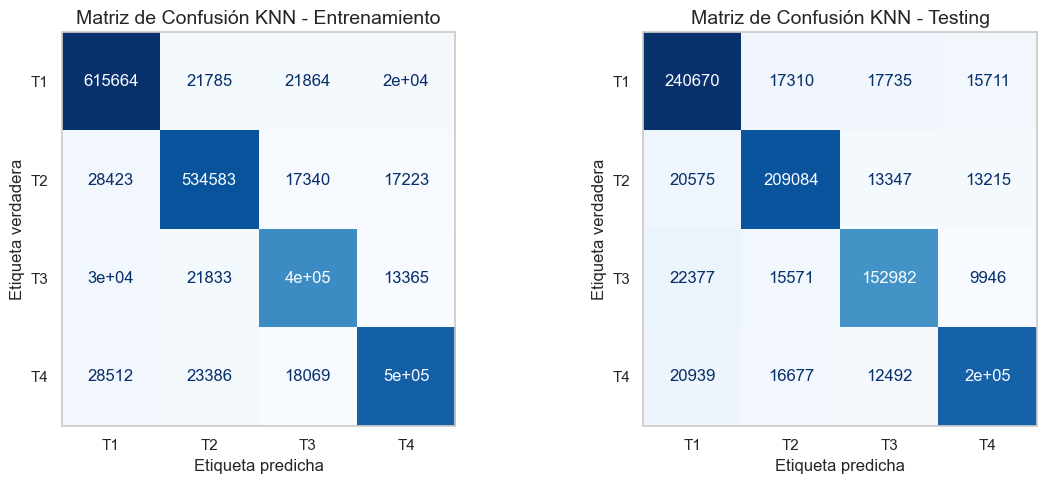

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

disp_train = ConfusionMatrixDisplay(confusion_matrix=knn_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión KNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

disp_test = ConfusionMatrixDisplay(confusion_matrix=knn_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión KNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.2 Predicciones con Random Forest

In [49]:
rf_prediction_test = make_prediction(rf_classifier, "test")

⏱️ RandomForestClassifier (test) predicho en 30.98s


In [50]:
rf_prediction_train = make_prediction(rf_classifier, "train")

⏱️ RandomForestClassifier (train) predicho en 52.60s


### 6.2.1 Guardar predicciones

In [51]:
joblib.dump(rf_prediction_test, "results/predictions/frijol/test/predicciones_rf_test.pkl")
joblib.dump(rf_prediction_train, "results/predictions/frijol/train/predicciones_rf_train.pkl")

['results/predictions/frijol/train/predicciones_rf_train.pkl']

### 6.2.2 Cargar predicciones

In [24]:
rf_prediction_test = joblib.load('results/predictions/frijol/test/predicciones_rf_test.pkl')
rf_prediction_train = joblib.load('results/predictions/frijol/train/predicciones_rf_train.pkl')

### 6.2.3 Resultados

In [52]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, rf_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    679294
           2       1.00      1.00      1.00    597569
           3       1.00      1.00      1.00    468604
           4       1.00      1.00      1.00    574648

    accuracy                           1.00   2320115
   macro avg       1.00      1.00      1.00   2320115
weighted avg       1.00      1.00      1.00   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.96      0.97      0.96    291426
           2       0.96      0.96      0.96    256221
           3       0.95      0.95      0.95    200876
           4       0.96      0.95      0.96    245812

    accuracy                           0.96    994335
   macro avg       0.96      0.96      0.96    994335
weighted avg       0.96      0.96      0.96    994335



In [27]:
rf_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=rf_prediction_train,
    labels=None,
    normalize=None,
)

rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_prediction_test,
    labels=None,
    normalize=None,
)

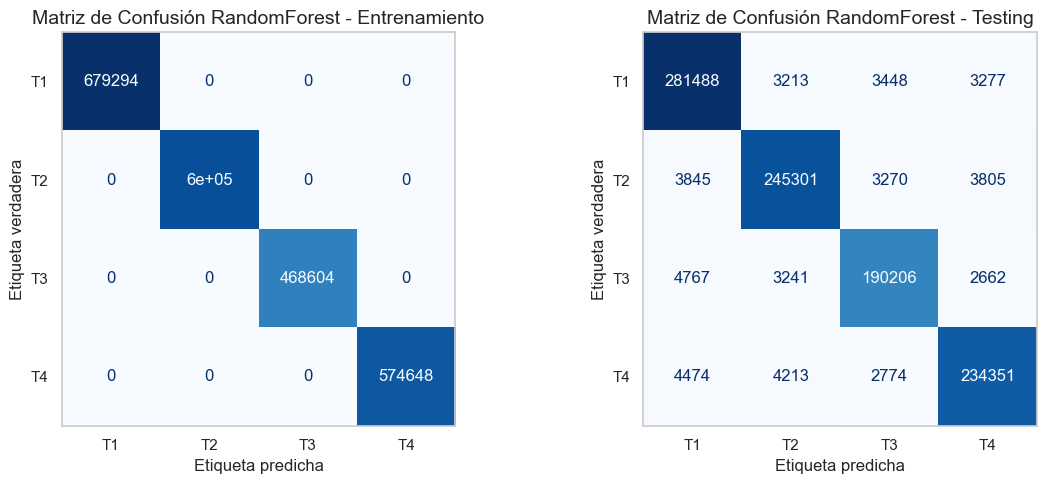

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión RandomForest - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión RandomForest - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.3 Predicciones con XGB

In [8]:
xgb_prediction_test = make_prediction(xgb_classifier, "test")

⏱️ XGBClassifier (test) predicho en 2.55s


In [9]:
xgb_prediction_train = make_prediction(xgb_classifier, "train")

⏱️ XGBClassifier (train) predicho en 5.48s


### 6.3.1 Guardar predicciones

In [10]:
joblib.dump(xgb_prediction_test, "results/predictions/frijol/test/predicciones_xgb_test.pkl")
joblib.dump(xgb_prediction_train, "results/predictions/frijol/train/predicciones_xgb_train.pkl")

['results/predictions/frijol/train/predicciones_xgb_train.pkl']

### 6.3.2 Cargar predicciones

In [ ]:
xgb_prediction_test = joblib.load('results/predictions/frijol/test/predicciones_xgb_test.pkl')
xgb_prediction_train = joblib.load('results/predictions/frijol/train/predicciones_xgb_train.pkl')

### 6.3.3 Resultados

In [11]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.76      0.78      0.77    679294
           1       0.74      0.78      0.76    597569
           2       0.73      0.67      0.70    468604
           3       0.77      0.77      0.77    574648

    accuracy                           0.75   2320115
   macro avg       0.75      0.75      0.75   2320115
weighted avg       0.75      0.75      0.75   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.76      0.78      0.77    291426
           1       0.74      0.77      0.76    256221
           2       0.73      0.67      0.70    200876
           3       0.77      0.77      0.77    245812

    accuracy                           0.75    994335
   macro avg       0.75      0.75      0.75    994335
weighted avg       0.75      0.75      0.75    994335



In [12]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_prediction_train,
    labels=None,
    normalize=None,
)
xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_prediction_test,
    labels=None,
    normalize=None,
)

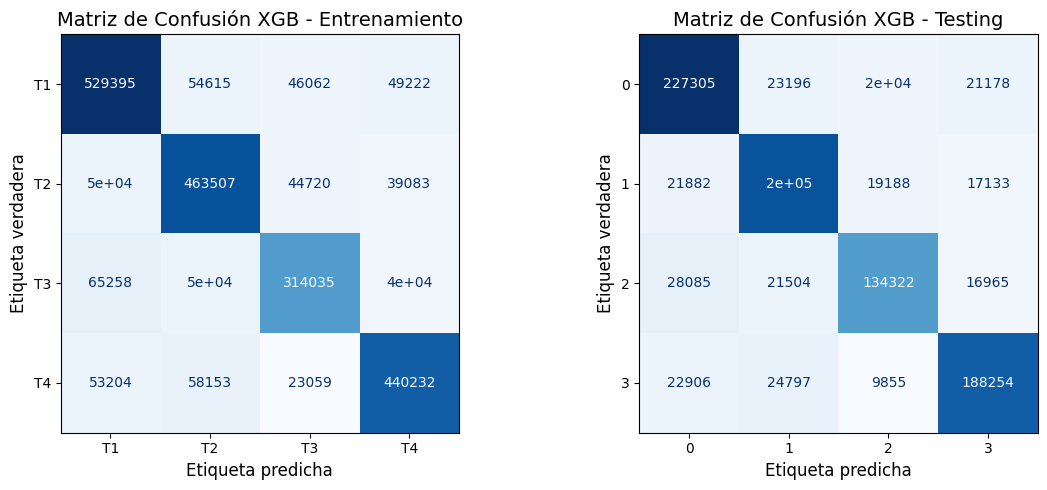

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión XGB - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_test)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión XGB - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.4 Predicciones con MLP

In [15]:
mlp_prediction_test = make_prediction(mlp_classifier, "test")

⏱️ MLPClassifier (test) predicho en 1.68s


In [16]:
mlp_prediction_train = make_prediction(mlp_classifier, "train")

⏱️ MLPClassifier (train) predicho en 3.80s


### 6.4.1 Guardar predicciones

In [17]:
joblib.dump(mlp_prediction_test, "results/predictions/frijol/test/predicciones_mlp_test.pkl")
joblib.dump(mlp_prediction_train, "results/predictions/frijol/train/predicciones_mlp_train.pkl")

['results/predictions/frijol/train/predicciones_mlp_train.pkl']

### 6.4.2 Cargar predicciones

In [ ]:
mlp_prediction_test = joblib.load('results/predictions/frijol/test/predicciones_mlp_test.pkl')
mlp_prediction_train = joblib.load('results/predictions/frijol/train/predicciones_mlp_train.pkl')

### 6.4.3 Resultados

In [18]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, mlp_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.50      0.58      0.54    679294
           2       0.59      0.56      0.58    597569
           3       0.51      0.36      0.42    468604
           4       0.56      0.61      0.59    574648

    accuracy                           0.54   2320115
   macro avg       0.54      0.53      0.53   2320115
weighted avg       0.54      0.54      0.54   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.50      0.59      0.54    291426
           2       0.59      0.56      0.58    256221
           3       0.51      0.36      0.42    200876
           4       0.56      0.61      0.59    245812

    accuracy                           0.54    994335
   macro avg       0.54      0.53      0.53    994335
weighted avg       0.54      0.54      0.54    994335



In [19]:
mlp_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=mlp_prediction_train,
    labels=None,
    normalize=None,
)
mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_prediction_test,
    labels=None,
    normalize=None,
)

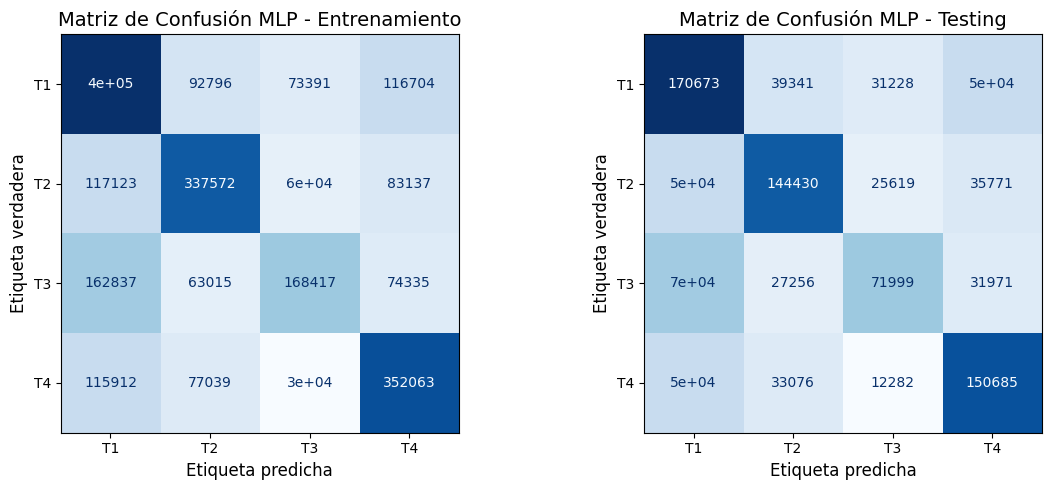

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión MLP - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión MLP - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# 7. Evaluación del modelo

In [28]:
classifiers_names = ["knn", "rfc", "xgb", "mlp"]
predictions_train = [knn_prediction_train, rf_prediction_train, xgb_prediction_train, mlp_prediction_train]
predictions_test = [knn_prediction_test, rf_prediction_test, xgb_prediction_test, mlp_prediction_test]
cmxs_train = [knn_cm_train, rf_cm_train, xgb_cm_train, mlp_cm_train]
cmxs_test = [knn_cm_test, rf_cm_test, xgb_cm_test, mlp_cm_test]

## 7.1 Entrenamiento

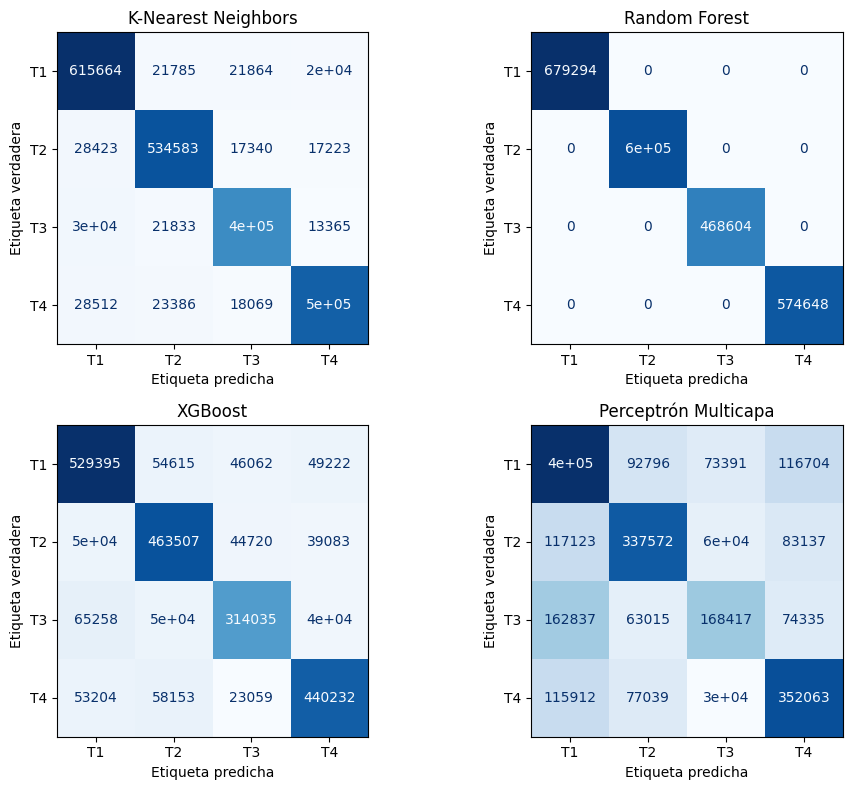

In [ ]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_train, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
results_list = []

for preds, classifier_name in zip(predictions_train, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_train_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_train, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_train_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_train, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

print("Métricas - Entrenamiento")
display(results_df.style.background_gradient(cmap='summer_r', axis=0))

Métricas - Entrenamiento


,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.887379,0.887634,0.887379,0.887347,0.848860
rfc,1.000000,1.000000,1.000000,1.000000,1.000000
xgb,0.757040,0.756965,0.757040,0.756691,0.673773
mlp,0.542170,0.543436,0.542170,0.532272,0.379790


## 7.2 Testing

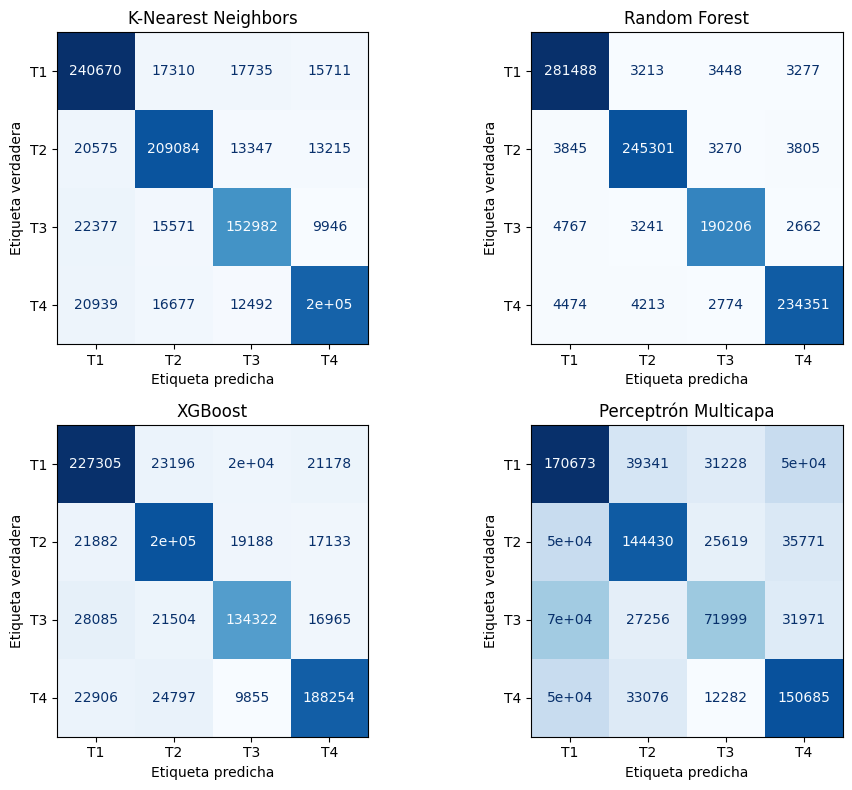

In [ ]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_test, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
results_list = []

for preds, classifier_name in zip(predictions_test, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_test_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_test, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_test_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_test, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.802169,0.802597,0.802169,0.802124,0.734465
rfc,0.958991,0.958994,0.958991,0.958982,0.945001
xgb,0.755720,0.755682,0.755720,0.755391,0.672030
mlp,0.541923,0.543086,0.541923,0.532012,0.379501


# 8. Seleccionar hiperparámetros

In [8]:
def make_rand_grid_search(estimator, param_dist,):

    randomizedSearchCV = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=12,
    refit=True)
    
    return randomizedSearchCV

In [18]:
def make_grid_search(estimator, param_dist,):

    knn_gridSearchCV = GridSearchCV(
    estimator=estimator,
    param_grid=param_dist,
    cv=5,
    scoring="accuracy",
    refit=True,
    )
    
    return knn_gridSearchCV

### 8.0.1 Guardar progreso

In [ ]:
# # Crear directorio para guardar modelos si no existe
os.makedirs('models/hyperparameter_tuning', exist_ok=True)
os.makedirs('models/best', exist_ok=True)

# Función para guardar progreso
def save_model_and_params(model, model_name, best_params, score, stage="hyperparameter_tuning"):
    """
    Guarda el modelo, sus mejores parámetros y el score obtenido
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Crear diccionario con toda la información
    model_info = {
        'model': model,
        'best_params': best_params,
        'best_score': score,
        'timestamp': timestamp,
        'model_name': model_name,
        'stage': stage
    }
    
    # Guardar en el directorio correspondiente
    save_path = f'models/frijol/{stage}/{model_name}_{timestamp}.pkl'
    
    with open(save_path, 'wb') as f:
        pickle.dump(model_info, f)
    
    print(f"✅ Modelo {model_name} guardado en: {save_path}")
    return save_path

In [5]:
# Función para cargar modelo guardado
def load_model_info(filepath):
    """
    Carga un modelo guardado y su información
    """
    with open(filepath, 'rb') as f:
        model_info = pickle.load(f)
    
    print(f"📁 Modelo {model_info['model_name']} cargado desde: {filepath}")
    print(f"   - Score: {model_info['best_score']:.4f}")
    print(f"   - Timestamp: {model_info['timestamp']}")
    
    return model_info

### 8.0.2 Recuperación de progreso

Cargar modelos previamente guardados.

In [ ]:
# Función para listar modelos guardados
def list_saved_models(stage="all"):
    """
    Lista todos los modelos guardados
    stage: 'hyperparameter_tuning', 'best', o 'all'
    """
    stages_to_check = []
    if stage == "all":
        stages_to_check = ["hyperparameter_tuning", "best"]
    else:
        stages_to_check = [stage]
    
    all_models = {}
    
    for stage_name in stages_to_check:
        path = f'models/frijol/{stage_name}'
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.endswith('.pkl')]
            if files:
                all_models[stage_name] = files
                print(f"\n📁 Modelos en {stage_name}:")
                for i, file in enumerate(files, 1):
                    print(f"  {i}. {file}")
    
    if not all_models:
        print("No se encontraron modelos guardados")
    
    return all_models

# Función para cargar el modelo más reciente de un tipo específico
def load_latest_model(model_name, stage="best"):
    """
    Carga el modelo más reciente de un tipo específico
    """
    path = f'models/frijol/{stage}'
    if not os.path.exists(path):
        print(f"❌ Directorio {path} no existe")
        return None
    
    # Buscar archivos que coincidan con el nombre del modelo
    files = [f for f in os.listdir(path) if f.startswith(model_name) and f.endswith('.pkl')]
    
    if not files:
        print(f"No se encontraron modelos de tipo {model_name} en {stage}")
        return None
    
    # Ordenar por fecha (timestamp en el nombre del archivo)
    files.sort(reverse=True)  # Más reciente primero
    latest_file = files[0]
    
    return load_model_info(os.path.join(path, latest_file))

In [ ]:
# Si se necesita recuperar progreso
print("🔍 Buscando modelos guardados...")
saved_models = list_saved_models()

🔍 Buscando modelos guardados...

📁 Modelos en hyperparameter_tuning:
  1. KNN_20251008_171051.pkl
  2. KNN_2_20251028_220337.pkl
  3. MLP_20251014_085414.pkl
  4. XGBoost_20251008_171837.pkl
  5. XGBoost_2_20251028_221907.pkl

📁 Modelos en best:
  1. KNN_final_20251030_183420.pkl
  2. KNN_final_2_20251028_220611.pkl
  3. MLP_final_20251017_112954.pkl
  4. RandomForest_final_2_20251028_225448.pkl
  5. XGBoost_final_20251008_172140.pkl
  6. XGBoost_final_2_20251028_222112.pkl


In [32]:
# Para cargar un modelo específico:
model_info = load_latest_model("KNN_final", "best")
knn_final = model_info['model']

📁 Modelo KNN_final cargado desde: models/frijol/best\KNN_final_2_20251028_220611.pkl
   - Score: 0.7543
   - Timestamp: 20251028_220611


In [12]:
# Para cargar un modelo específico:
model_info = load_latest_model("XGBoost_final", "best")
xgb_final = model_info['model']

📁 Modelo XGBoost_final cargado desde: models/frijol/best\XGBoost_final_2_20251028_222112.pkl
   - Score: 0.8920
   - Timestamp: 20251028_222112


In [13]:
# Para cargar un modelo específico:
model_info = load_latest_model("MLP_final", "best")
mlp_final = model_info['model']

📁 Modelo MLP_final cargado desde: models/frijol/best\MLP_final_20251017_112954.pkl
   - Score: 0.6755
   - Timestamp: 20251017_112954


In [14]:
# Para cargar un modelo específico:
model_info = load_latest_model("RandomForest_final", "best")
rf_final = model_info['model']

📁 Modelo RandomForest_final cargado desde: models/frijol/best\RandomForest_final_2_20251028_225448.pkl
   - Score: 0.8433
   - Timestamp: 20251028_225448


## 8.1 Selección de muestra

Para acelerar la búsqueda de hiperparámetros, se trabaja con una muestra representativa del dataset de entrenamiento. Una vez encontrados los mejores parámetros, se entrena con el dataset completo.

In [5]:
# Configuración del tamaño de muestra para hiperparámetros
HYPERPARAMETER_SAMPLE_SIZE = 0.15  # 15% del dataset de entrenamiento
RANDOM_STATE = 42

print(f"Dataset original de entrenamiento: {X_train_scaled.shape[0]:,} muestras")

# Crear muestra estratificada manteniendo la proporción de clases
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, 
    y_train,
    test_size=1-HYPERPARAMETER_SAMPLE_SIZE,  # Tomar solo el 15%
    stratify=y_train,  # Mantener proporción de clases
    random_state=RANDOM_STATE
)

# Para XGBoost versión codificada
y_train_sample_encoded = le.transform(y_train_sample)

print(f"Muestra para hiperparámetros: {X_train_sample.shape[0]:,} muestras ({HYPERPARAMETER_SAMPLE_SIZE*100:.1f}%)")
print(f"Reducción de tiempo estimada: ~{(1/HYPERPARAMETER_SAMPLE_SIZE):.1f}x más rápido")

# Verificar distribución de clases en la muestra
print("\nDistribución de clases en muestra para hiperparámetros:")
print(pd.Series(y_train_sample).value_counts().sort_index())

Dataset original de entrenamiento: 2,320,115 muestras
Muestra para hiperparámetros: 348,017 muestras (15.0%)
Reducción de tiempo estimada: ~6.7x más rápido

Distribución de clases en muestra para hiperparámetros:
1    101894
2     89635
3     70291
4     86197
Name: count, dtype: int64


## 8.2 KNeighbors - Búsqueda de hiperparámetros

In [8]:
knn_param_grid = [
    {
        'n_neighbors': np.arange(1, 10, 1), 
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }
]

In [9]:
print("🔍 Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    # Usar muestra para búsqueda de hiperparámetros
    knn_gridSearchCV = make_rand_grid_search(KNeighborsClassifier(n_jobs=-1), knn_param_grid)
    knn_gridSearchCV.fit(X_train_sample, y_train_sample)
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=knn_gridSearchCV,
        model_name="KNN",
        best_params=knn_gridSearchCV.best_params_,
        score=knn_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros KNN completada exitosamente")
    print(f"Best Score: {knn_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros KNN: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...
Muestra: 348,017 registros
✅ Modelo KNN guardado en: models/frijol/hyperparameter_tuning/KNN_2_20251028_220337.pkl
✅ Búsqueda de hiperparámetros KNN completada exitosamente
Best Score: 0.7543


In [10]:
print("🎯 Mejores parámetros encontrados para KNN:")
print(knn_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {knn_gridSearchCV.best_score_:.4f}")

# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando KNN con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
knn_final = KNeighborsClassifier(n_jobs=-1, **knn_gridSearchCV.best_params_)
knn_final.fit(X_train_scaled, y_train)

# Guardar modelo final
final_save_path = save_model_and_params(
    model=knn_final,
    model_name="KNN_final",
    best_params=knn_gridSearchCV.best_params_,
    score=knn_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo KNN final entrenado y guardado")

🎯 Mejores parámetros encontrados para KNN:
{'weights': 'distance', 'n_neighbors': np.int64(9), 'metric': 'euclidean'}
Score de validación cruzada: 0.7543

🚀 Entrenando KNN con dataset completo (2,320,115 muestras)...
✅ Modelo KNN_final guardado en: models/frijol/best/KNN_final_2_20251028_220611.pkl
✅ Modelo KNN final entrenado y guardado


In [7]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando KNN con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
knn_final = KNeighborsClassifier(n_jobs=-1, **{'weights': 'distance', 'n_neighbors': np.int64(2), 'metric': 'manhattan'})
knn_final.fit(X_train_scaled, y_train)

# Guardar modelo final
final_save_path = save_model_and_params(
    model=knn_final,
    model_name="KNN_final",
    best_params={'weights': 'distance', 'n_neighbors': np.int64(2), 'metric': 'manhattan'},
    score=0.7540,
    stage="best"
)

print("✅ Modelo KNN final entrenado y guardado")


🚀 Entrenando KNN con dataset completo (2,320,115 muestras)...
✅ Modelo KNN_final guardado en: models/frijol/best/KNN_final_20251030_183420.pkl
✅ Modelo KNN final entrenado y guardado


### 8.2.1 Predicciones

In [15]:
# Usar modelo final para predicciones
knn_y_train_pred = knn_final.predict(X_train_scaled)
knn_y_test_pred = knn_final.predict(X_test_scaled)

#### Guardar predicciones

In [37]:
joblib.dump(knn_y_test_pred, "predictions/frijol/test/best_predicciones_knn_test.pkl")

['predictions/frijol/test/best_predicciones_knn_test.pkl']

In [38]:
joblib.dump(knn_y_train_pred, "predictions/frijol/train/best_predicciones_knn_train.pkl")

['predictions/frijol/train/best_predicciones_knn_train.pkl']

#### Cargar predicciones

In [14]:
knn_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_knn_test.pkl')

In [15]:
knn_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_knn_train.pkl')

### 8.2.2 Resultados

In [ ]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, knn_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    679792
           2       1.00      1.00      1.00    597723
           3       1.00      1.00      1.00    468638
           4       1.00      1.00      1.00    573962

    accuracy                           1.00   2320115
   macro avg       1.00      1.00      1.00   2320115
weighted avg       1.00      1.00      1.00   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.90      0.90      0.90    290928
           2       0.90      0.89      0.90    256067
           3       0.88      0.88      0.88    200842
           4       0.89      0.89      0.89    246498

    accuracy                           0.89    994335
   macro avg       0.89      0.89      0.89    994335
weighted avg       0.89      0.89      0.89    994335



In [16]:
knn_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=knn_y_train_pred,
    labels=None,
    normalize=None,
)

In [17]:
knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_y_test_pred,
    labels=None,
    normalize=None,
)

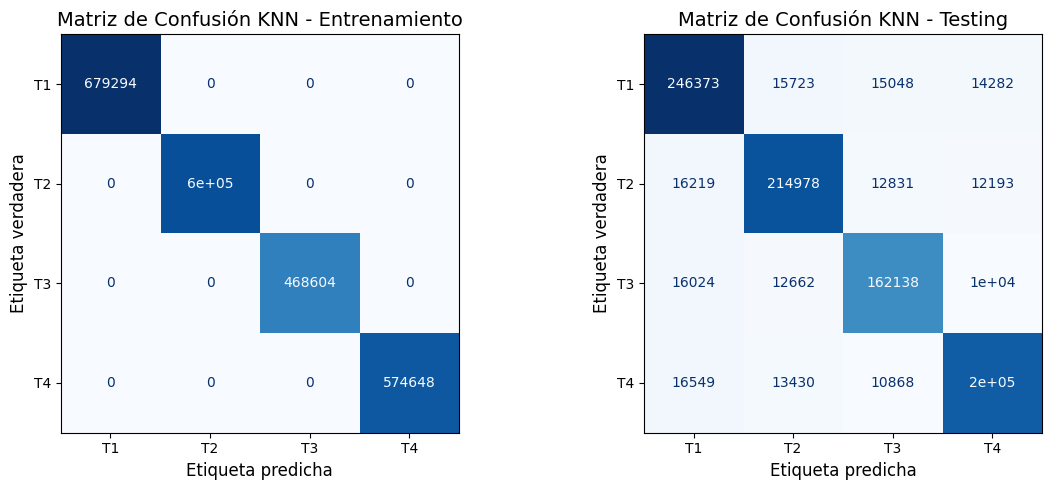

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

disp_train = ConfusionMatrixDisplay(confusion_matrix=knn_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión KNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

disp_test = ConfusionMatrixDisplay(confusion_matrix=knn_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión KNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Interpretación de las matrices de confusión - KNN Optimizado:**

**Comparación Entrenamiento vs. Testing:**

*Entrenamiento:*
- Valores muy altos en la diagonal principal
- Pocas clasificaciones erróneas
- Rendimiento balanceado entre las cuatro clases

*Testing:*
- Ligera disminución en la diagonal principal comparado con entrenamiento
- Aumento moderado de confusiones fuera de la diagonal
- Patrón de errores más distribuido

La simetría en los errores sugiere que el modelo no tiene sesgos hacia clases específicas. Se percibe overfitting.

## 8.3 Random Forest - Búsqueda de hiperparámetros

In [6]:
rf_param_grid = [
    {
        'n_estimators': [50, 100, 150], 
        'max_depth': [5,10,None],
    }
]

In [ ]:
print("🔍 Iniciando búsqueda de hiperparámetros para Random Forest con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    # Usar muestra para búsqueda de hiperparámetros
    rf_gridSearchCV = make_rand_grid_search(RandomForestClassifier(n_jobs=-1, random_state=12), rf_param_grid)
    rf_gridSearchCV.fit(X_train_sample, y_train_sample)
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=rf_gridSearchCV,
        model_name="RandomForest",
        best_params=rf_gridSearchCV.best_params_,
        score=rf_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros Random Forest completada exitosamente")
    print(f"Best Score: {rf_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros Random Forest: {e}")
    raise

In [11]:
print("🎯 Mejores parámetros encontrados para Random Forest:")
print(rf_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {rf_gridSearchCV.best_score_:.4f}")

# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando Random Forest con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_gridSearchCV.best_params_)
rf_final.fit(X_train_scaled, y_train)

# Guardar modelo final
final_save_path = save_model_and_params(
    model=rf_final,
    model_name="RandomForest_final",
    best_params=rf_gridSearchCV.best_params_,
    score=rf_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo Random Forest final entrenado y guardado")

🎯 Mejores parámetros encontrados para Random Forest:
{'n_estimators': 150, 'max_depth': None}
Score de validación cruzada: 0.8433

🚀 Entrenando Random Forest con dataset completo (2,320,115 muestras)...
✅ Modelo RandomForest_final guardado en: models/frijol/best/RandomForest_final_2_20251028_225448.pkl
✅ Modelo Random Forest final entrenado y guardado


### 8.3.1 Predicciones

In [39]:
# Usar modelo final para predicciones
rf_y_train_pred = rf_final.predict(X_train_scaled)
rf_y_test_pred = rf_final.predict(X_test_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(rf_y_test_pred, "results/predictions/frijol/test/best_predicciones_rf_test.pkl")

In [ ]:
joblib.dump(rf_y_train_pred, "results/predictions/frijol/train/best_predicciones_rf_train.pkl")

['predictions/frijol/train/best_predicciones_rf_train.pkl']

#### Cargar predicciones

In [21]:
rf_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_rf_test.pkl')

In [22]:
rf_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_rf_train.pkl')

### 8.3.2 Resultados

In [19]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, rf_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    679374
           2       1.00      1.00      1.00    597345
           3       1.00      1.00      1.00    468674
           4       1.00      1.00      1.00    574722

    accuracy                           1.00   2320115
   macro avg       1.00      1.00      1.00   2320115
weighted avg       1.00      1.00      1.00   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.96      0.97      0.96    291346
           2       0.96      0.96      0.96    256445
           3       0.95      0.95      0.95    200806
           4       0.96      0.95      0.96    245738

    accuracy                           0.96    994335
   macro avg       0.96      0.96      0.96    994335
weighted avg       0.96      0.96      0.96    994335



In [54]:
rf_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=rf_y_train_pred,
    labels=None,
    normalize=None,
)

In [55]:
rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_y_test_pred,
    labels=None,
    normalize=None,
)

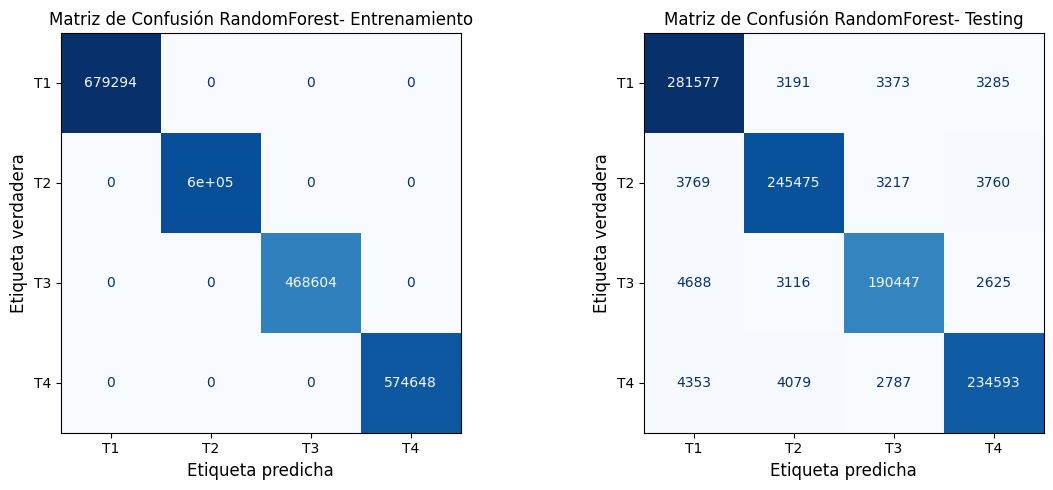

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión RandomForest- Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión RandomForest- Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Interpretación de las matrices de confusión - Random Forest Optimizado:**

*Entrenamiento:*
- Diagonal principal muy pronunciada con valores altos
- Random Forest tiende a memorizar bien los datos de entrenamiento
- Clasificaciones casi perfectas debido a la naturaleza ensemble del algoritmo

*Testing:*
- Rendimiento robusto mantenido en datos no vistos
- La disminución train→test es típica para Random Forest
- Los errores de clasificación están distribuidos de manera relativamente uniforme

## 8.4 XGB - Búsqueda de hiperparámetros

In [12]:
xgb_param_grid = [
    {
        'n_estimators': [50, 100, 200], 
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
]

In [13]:
print("🔍 Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    # Usar muestra para búsqueda de hiperparámetros
    xgb_gridSearchCV = make_rand_grid_search(xgb.XGBClassifier(random_state=42), xgb_param_grid)
    xgb_gridSearchCV.fit(X_train_sample, y_train_sample_encoded)
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=xgb_gridSearchCV,
        model_name="XGBoost",
        best_params=xgb_gridSearchCV.best_params_,
        score=xgb_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros XGBoost completada exitosamente")
    print(f"Best Score: {xgb_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros XGBoost: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...
Muestra: 348,017 registros
✅ Modelo XGBoost guardado en: models/frijol/hyperparameter_tuning/XGBoost_2_20251028_221907.pkl
✅ Búsqueda de hiperparámetros XGBoost completada exitosamente
Best Score: 0.8920


In [14]:
print("🎯 Mejores parámetros encontrados para XGB:")
print(xgb_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {xgb_gridSearchCV.best_score_:.4f}")

print(f"\n🚀 Entrenando XGBoost con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
xgb_final = xgb.XGBClassifier(random_state=42, **xgb_gridSearchCV.best_params_)
xgb_final.fit(X_train_scaled, y_train_encoded)

# Guardar modelo final
final_save_path = save_model_and_params(
    model=xgb_final,
    model_name="XGBoost_final",
    best_params=xgb_gridSearchCV.best_params_,
    score=xgb_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo XGBoost final entrenado y guardado")

🎯 Mejores parámetros encontrados para XGB:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.2}
Score de validación cruzada: 0.8920

🚀 Entrenando XGBoost con dataset completo (2,320,115 muestras)...
✅ Modelo XGBoost_final guardado en: models/frijol/best/XGBoost_final_2_20251028_222112.pkl
✅ Modelo XGBoost final entrenado y guardado


### 8.4.1 Predicciones

In [42]:
# Usar modelo final para predicciones
xgb_y_train_pred = xgb_final.predict(X_train_scaled)
xgb_y_test_pred = xgb_final.predict(X_test_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(xgb_y_test_pred, "results/predictions/frijol/test/best_predicciones_xgb_test.pkl")

In [ ]:
joblib.dump(xgb_y_train_pred, "results/predictions/frijol/train/best_predicciones_xgb_train.pkl")

['predictions/frijol/train/best_predicciones_xgb_train.pkl']

#### Cargar predicciones

In [24]:
xgb_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_xgb_test.pkl')

In [25]:
xgb_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_xgb_train.pkl')

### 8.4.2 Resultados

In [16]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.91      0.93      0.92    679782
           1       0.89      0.90      0.89    597036
           2       0.89      0.87      0.88    468753
           3       0.91      0.91      0.91    574544

    accuracy                           0.90   2320115
   macro avg       0.90      0.90      0.90   2320115
weighted avg       0.90      0.90      0.90   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.91      0.92      0.92    290938
           1       0.89      0.89      0.89    256754
           2       0.89      0.86      0.88    200727
           3       0.90      0.90      0.90    245916

    accuracy                           0.90    994335
   macro avg       0.90      0.90      0.90    994335
weighted avg       0.90      0.90      0.90    994335



In [60]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_y_train_pred,
    labels=None,
    normalize=None,
)

xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_y_test_pred,
    labels=None,
    normalize=None,
)

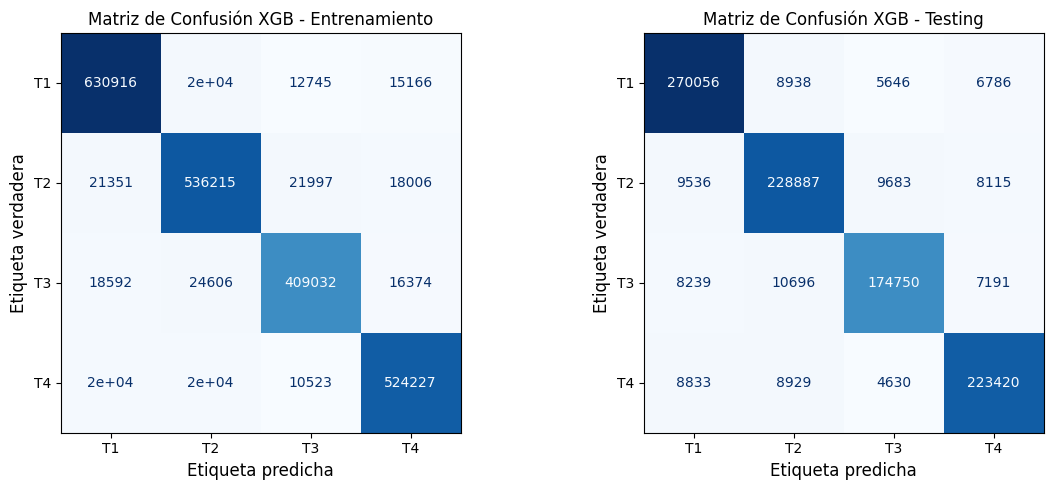

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión XGB - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión XGB - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Interpretación de las matrices de confusión - XGBoost Optimizado:**

*Entrenamiento:*
- Diagonal fuerte
- Errores relativamente bajos fuera de la diagonal
- Rendimiento sobresaliente típico de XGBoost en datos de entrenamiento

*Testing:*
- Mantiene excelente rendimiento en datos no vistos
- Diagonal principal sigue siendo muy prominente
- Los errores minoritarios probablemente en transiciones T2↔T3 (deficiencias moderadas-leves)

## 8.5 MLP - Búsqueda de hiperparámetros

In [12]:
mlp_param_grid = [
    {
        'hidden_layer_sizes': [(50,50), (100, 50), (150, 100, 50)], 
        'batch_size': [64, 256],
        'learning_rate_init': [0.001, 0.01],
        'alpha': [1e-4, 1e-5],
        'early_stopping' : [True]
    }
]

In [13]:
print("🔍 Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    # Usar muestra para búsqueda de hiperparámetros
    mlp_gridSearchCV = make_rand_grid_search(MLPClassifier(), mlp_param_grid)
    mlp_gridSearchCV.fit(X_train_sample, y_train_sample)
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=mlp_gridSearchCV,
        model_name="MLP",
        best_params=mlp_gridSearchCV.best_params_,
        score=mlp_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros MLP completada exitosamente")
    print(f"Best Score: {mlp_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error during MLP hyperparameter search: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...
Muestra: 348,017 registros
✅ Modelo MLP guardado en: models/hyperparameter_tuning/MLP_20251014_085414.pkl
✅ Búsqueda de hiperparámetros MLP completada exitosamente
Best Score: 0.6755


In [14]:
print("🎯 Mejores parámetros encontrados para MLP:")
print(mlp_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {mlp_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para MLP:
{'learning_rate_init': 0.001, 'hidden_layer_sizes': (150, 100, 50), 'early_stopping': True, 'batch_size': 256, 'alpha': 0.0001}
Score de validación cruzada: 0.6755


In [4]:
mlp_best_params = {'learning_rate_init': 0.001, 'hidden_layer_sizes': (150, 100, 50), 'early_stopping': True, 'batch_size': 256, 'alpha': 0.0001}

In [ ]:
# Entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando MLP con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
mlp_final = MLPClassifier(**mlp_best_params)
# mlp_final = MLPClassifier(**mlp_gridSearchCV.best_params_)
mlp_final.fit(X_train_scaled, y_train)

# Guardar modelo final
final_save_path = save_model_and_params(
    model=mlp_final,
    model_name="MLP_final",
    best_params=mlp_gridSearchCV.best_params_,
    score=mlp_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo MLP final entrenado y guardado")


🚀 Entrenando MLP con dataset completo (2,320,115 muestras)...
✅ Modelo MLP final entrenado y guardado


In [ ]:
# Guardar modelo final
final_save_path = save_model_and_params(
    model=mlp_final,
    model_name="MLP_final",
    best_params=mlp_gridSearchCV.best_params_,
    best_params=mlp_best_params,
    score=0.6755,
    stage="best"
)

✅ Modelo MLP_final guardado en: models/best/MLP_final_20251017_112954.pkl


### 8.5.1 Predicciones

In [45]:
# Usar modelo final para predicciones
mlp_y_test_pred = mlp_final.predict(X_test_scaled)

In [46]:
mlp_y_train_pred = mlp_final.predict(X_train_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(mlp_y_test_pred, "results/predictions/frijol/test/best_predicciones_mlp_test.pkl")

In [ ]:
joblib.dump(mlp_y_train_pred, "results/predictions/frijol/train/best_predicciones_mlp_train.pkl")

['predictions/frijol/train/best_predicciones_mlp_train.pkl']

#### Cargar predicciones

In [27]:
mlp_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_mlp_test.pkl')

In [28]:
mlp_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_mlp_train.pkl')

### 8.5.2 Resultados

In [10]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, mlp_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.77      0.71      0.74    679849
           2       0.77      0.76      0.76    597339
           3       0.70      0.72      0.71    468725
           4       0.74      0.79      0.76    574202

    accuracy                           0.75   2320115
   macro avg       0.74      0.75      0.75   2320115
weighted avg       0.75      0.75      0.75   2320115


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.77      0.71      0.74    290871
           2       0.77      0.76      0.77    256451
           3       0.70      0.72      0.71    200755
           4       0.74      0.79      0.76    246258

    accuracy                           0.75    994335
   macro avg       0.74      0.75      0.74    994335
weighted avg       0.75      0.75      0.75    994335



In [64]:
mlp_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=mlp_y_train_pred,
    labels=None,
    normalize=None,
)

mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_y_test_pred,
    labels=None,
    normalize=None,
)

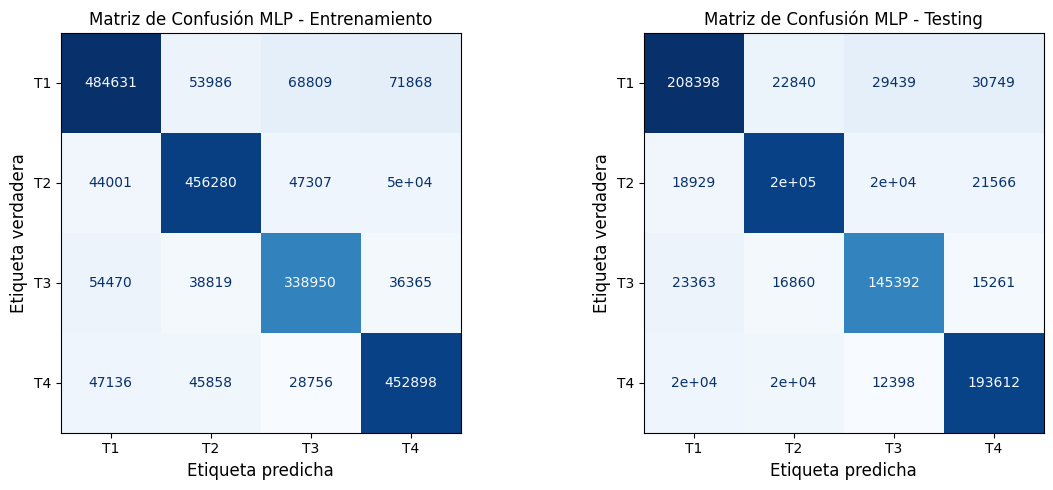

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión MLP - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión MLP - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Interpretación de las matrices de confusión - MLP Optimizado:**

*Entrenamiento:*
- Diagonal principal visible pero con menor intensidad que XGBoost/RF
- Presencia notable de confusiones fuera de la diagonal
- Rendimiento moderado que sugiere arquitectura subóptima o convergencia parcial

*Testing:*
- Patrón similar al entrenamiento (buena señal de no overfitting)
- Errores distribuidos entre múltiples clases
- Dificultad particular para discriminar clases intermedias (T2, T3)

**Posibles mejoras:**
- Probar arquitecturas más profundas o diferentes (e.g., [200, 200, 100])
- Experimentar con funciones de activación alternativas (ReLU, LeakyReLU)
- Aumentar épocas de entrenamiento con early stopping más permisivo
- Considerar regularización dropout

MLP muestra el rendimiento más bajo entre los cuatro modelos optimizados. Sin embargo, su consistencia train-test indica estabilidad. Para este problema específico, los métodos basados en árboles (RF, XGBoost) y métodos basados en instancias (KNN) superan a las redes neuronales tradicionales.

## 8.6. Comparación final de modelos optimizados

Después de la búsqueda de hiperparámetros y entrenamiento con el dataset completo se compara el rendimiento de todos los modelos optimizados.

In [29]:
# Compilar resultados de todos los modelos optimizados
final_models = [
    ('KNN Optimizado', knn_y_train_pred, knn_y_test_pred),
    ('Random Forest Optimizado', rf_y_train_pred, rf_y_test_pred),
    ('XGBoost Optimizado', xgb_y_train_pred, xgb_y_test_pred),
    ('MLP Optimizado', mlp_y_train_pred, mlp_y_test_pred)
]

In [ ]:
final_results = []

for model_name, train_pred, test_pred in final_models:
    # Para XGBoost usamos las versiones encoded
    if 'XGBoost' in model_name:
        train_report = classification_report(y_train_encoded, train_pred, output_dict=True)
        test_report = classification_report(y_test_encoded, test_pred, output_dict=True)
        train_kappa = cohen_kappa_score(y_train_encoded, train_pred)
        test_kappa = cohen_kappa_score(y_test_encoded, test_pred)
    else:
        train_report = classification_report(y_train, train_pred, output_dict=True)
        test_report = classification_report(y_test, test_pred, output_dict=True)
        train_kappa = cohen_kappa_score(y_train, train_pred)
        test_kappa = cohen_kappa_score(y_test, test_pred)
    
    final_results.append({
        'Modelo': model_name,
        'Train Accuracy': train_report['accuracy'],
        'Test Accuracy': test_report['accuracy'],
        'Train Precision': train_report['weighted avg']['precision'],
        'Test Precision': test_report['weighted avg']['precision'],
        'Train Recall': train_report['weighted avg']['recall'],
        'Test Recall': test_report['weighted avg']['recall'],
        'Train F1-Score': train_report['weighted avg']['f1-score'],
        'Test F1-Score': test_report['weighted avg']['f1-score'],
        'Train Kappa': train_kappa,
        'Test Kappa': test_kappa,
        'Overfitting': abs(train_report['accuracy'] - test_report['accuracy'])
    })

final_results_df = pd.DataFrame(final_results)
final_results_df = final_results_df.set_index('Modelo')

print("🏆 RESULTADOS FINALES - MODELOS OPTIMIZADOS")
print("=" * 60)
display(final_results_df.style.background_gradient(cmap='RdYlGn', axis=0).format(precision=4))

# Encontrar el mejor modelo
best_model_idx = final_results_df['Test Accuracy'].idxmax()
best_score = final_results_df.loc[best_model_idx, 'Test Accuracy']

print(f"\n🥇 MEJOR MODELO: {best_model_idx}")
print(f"   Test Accuracy: {best_score:.4f}")
print(f"   Test F1-Score: {final_results_df.loc[best_model_idx, 'Test F1-Score']:.4f}")
print(f"   Overfitting: {final_results_df.loc[best_model_idx, 'Overfitting']:.4f}")

🏆 RESULTADOS FINALES - MODELOS OPTIMIZADOS


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score,Train Kappa,Test Kappa,Overfitting
Modelo,,,,,,,,,,,
KNN Optimizado,1.0000,0.8936,1.0000,0.8935,1.0000,0.8936,1.0000,0.8935,1.0000,0.8573,0.1064
Random Forest Optimizado,1.0000,0.9575,1.0000,0.9575,1.0000,0.9575,1.0000,0.9575,1.0000,0.9430,0.0425
XGBoost Optimizado,0.9053,0.9022,0.9053,0.9022,0.9053,0.9022,0.9052,0.9021,0.8729,0.8688,0.0031
MLP Optimizado,0.7468,0.7469,0.7477,0.7478,0.7468,0.7469,0.7468,0.7469,0.6611,0.6613,0.0001



🥇 MEJOR MODELO: Random Forest Optimizado
   Test Accuracy: 0.9575
   Test F1-Score: 0.9575
   Overfitting: 0.0425


# 9. Análisis de costos computacionales

## 9.1 Resultados Modelos Baseline

In [44]:
# Datos consolidados de las secciones anteriores y tiempos registrados
performance_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.802169, 0.958991, 0.755720, 0.541923],
    'Kappa_Score': [0.734465, 0.945001, 0.672030, 0.379501], 
    'Tiempo_Entrenamiento_Seg': [6, 256, 35, 139],
    'Tiempo_Texto': ['6 seg', '256 seg', '35 seg', '139 seg']
}

df_perf = pd.DataFrame(performance_data)

# Mostrar tabla resumen
display(df_perf.style.background_gradient(subset=['Accuracy_Test', 'Kappa_Score'], cmap='Greens').background_gradient(subset=['Tiempo_Entrenamiento_Seg'], cmap='Reds'))

,Modelo,Accuracy_Test,Kappa_Score,Tiempo_Entrenamiento_Seg,Tiempo_Texto
0,KNN,0.802169,0.734465,6,6 seg
1,Random Forest,0.958991,0.945001,256,256 seg
2,XGBoost,0.755720,0.672030,35,35 seg
3,MLP,0.541923,0.379501,139,139 seg


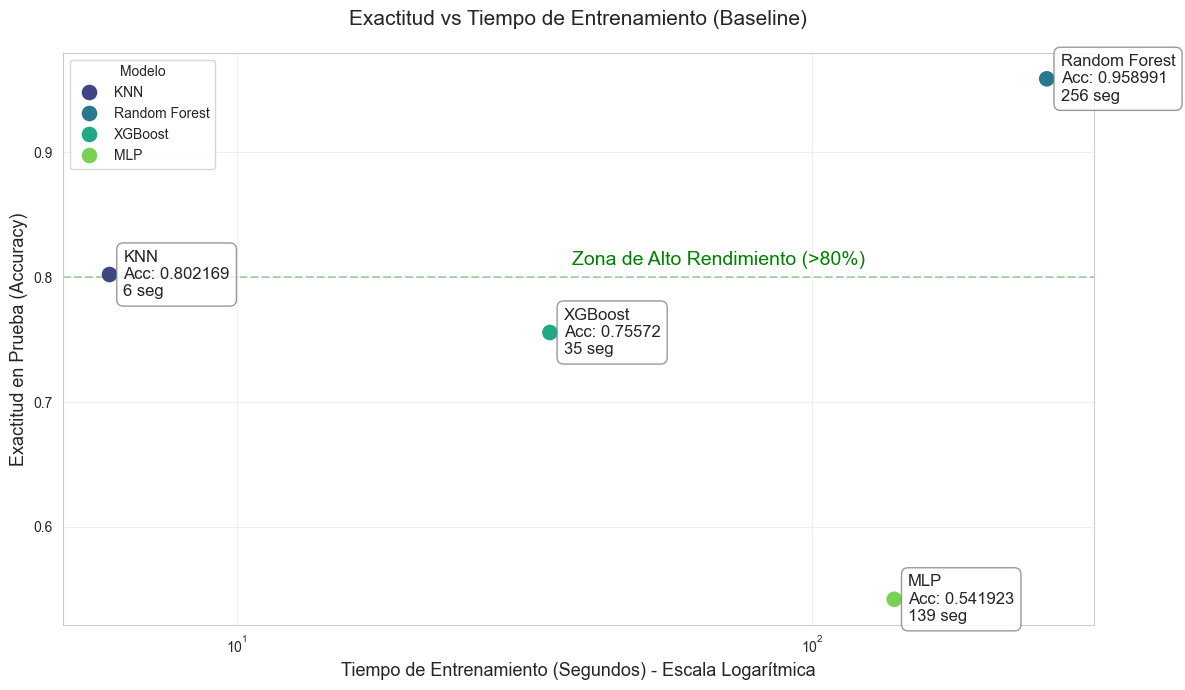

In [ ]:
# Visualización de la Frontera de Pareto (Accuracy vs Tiempo)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Scatter plot - todos círculos más pequeños
scatter = sns.scatterplot(
    data=df_perf, 
    x='Tiempo_Entrenamiento_Seg', 
    y='Accuracy_Test', 
    s=150, 
    hue='Modelo', 
    palette='viridis'
)

# Escala logarítmica en X debido a la gran disparidad de tiempos (segundos vs días)
plt.xscale('log')

# Etiquetas y Títulos
plt.title('Exactitud vs Tiempo de Entrenamiento (Baseline)', fontsize=15, pad=20)
plt.xlabel('Tiempo de Entrenamiento (Segundos) - Escala Logarítmica', fontsize=13)
plt.ylabel('Exactitud en Prueba (Accuracy)', fontsize=13)

# Hacer la grilla más transparente
plt.grid(alpha=0.3)

# Anotaciones con alineación vertical centrada y letra más grande
for i in range(df_perf.shape[0]):
    plt.annotate(
        f"{df_perf.Modelo[i]}\nAcc: {df_perf.Accuracy_Test[i]}\n{df_perf.Tiempo_Texto[i]}", 
        (df_perf.Tiempo_Entrenamiento_Seg[i], df_perf.Accuracy_Test[i]),
        xytext=(10, 0), textcoords='offset points',
        va='center',  # Alineación vertical centrada con el símbolo
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
    )

# Marcar la región óptima (Alta exactitud, bajo tiempo)
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
# Posicionar el texto a la derecha con letra más grande
plt.text(plt.xlim()[1] * 0.4, 0.81, 'Zona de Alto Rendimiento (>80%)', 
         color='green', ha='right', fontsize=14)

plt.tight_layout()
plt.show()

## 9.2 Resultados Modelos optimizados

In [ ]:
# Datos consolidados de las secciones anteriores y tiempos registrados
performance_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.8936, 0.9575, 0.9022, 0.7469],
    'Kappa_Score': [0.8573, 0.9430, 0.8688, 0.6613], 
    'Tiempo_Entrenamiento_Min': [0.1, 7.3, 1.2, 2920],
    'Tiempo_Texto': ['6 seg', '7 min 18s', '1 min 12s', '2920 min']
}

df_perf = pd.DataFrame(performance_data)

# Mostrar tabla resumen
display(df_perf.style.background_gradient(subset=['Accuracy_Test', 'Kappa_Score'], cmap='Greens').background_gradient(subset=['Tiempo_Entrenamiento_Min'], cmap='Reds'))

,Modelo,Accuracy_Test,Kappa_Score,Tiempo_Entrenamiento_Min,Tiempo_Texto
0,KNN,0.893600,0.857300,0.100000,6 seg
1,Random Forest,0.957500,0.943000,7.300000,7 min 18s
2,XGBoost,0.902200,0.868800,1.200000,1 min 12s
3,MLP,0.746900,0.661300,2920.000000,2920 min


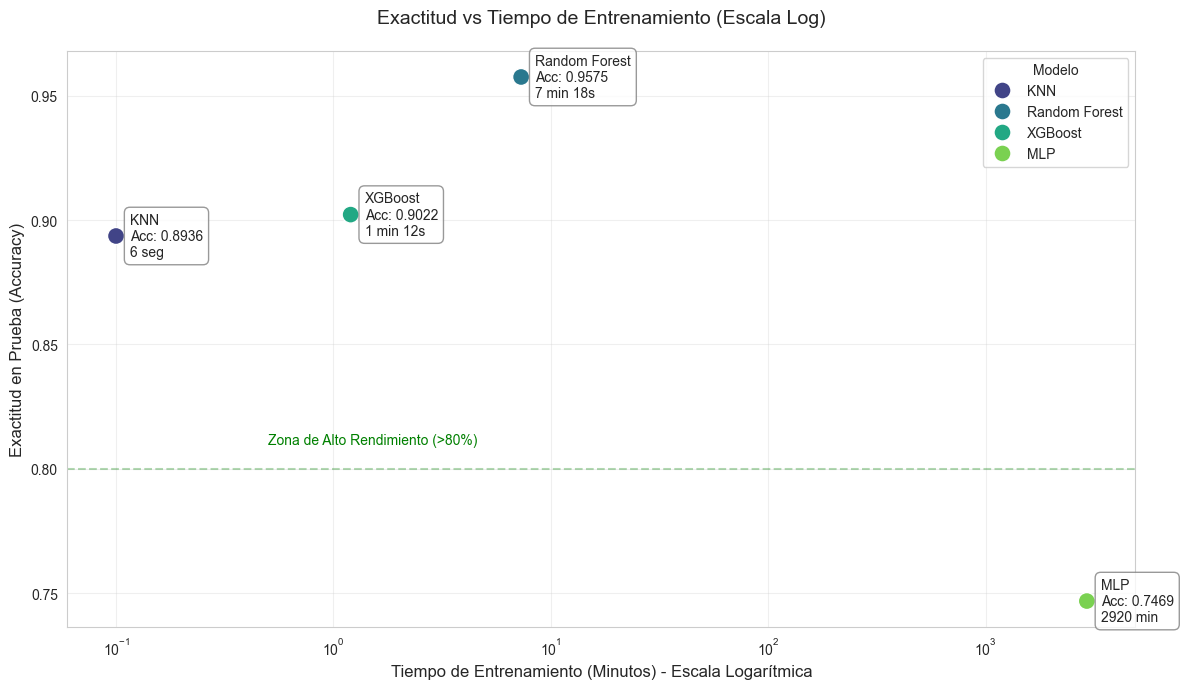

In [39]:
# Visualización de la Frontera de Pareto (Accuracy vs Tiempo)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Scatter plot - todos círculos más pequeños
scatter = sns.scatterplot(
    data=df_perf, 
    x='Tiempo_Entrenamiento_Min', 
    y='Accuracy_Test', 
    s=150, 
    hue='Modelo', 
    palette='viridis'
)

# Escala logarítmica en X debido a la gran disparidad de tiempos (segundos vs días)
plt.xscale('log')

# Etiquetas y Títulos
plt.title('Exactitud vs Tiempo de Entrenamiento (Escala Log)', fontsize=14, pad=20)
plt.xlabel('Tiempo de Entrenamiento (Minutos) - Escala Logarítmica', fontsize=12)
plt.ylabel('Exactitud en Prueba (Accuracy)', fontsize=12)

# Hacer la grilla más transparente
plt.grid(alpha=0.3)

# Anotaciones con alineación vertical centrada
for i in range(df_perf.shape[0]):
    plt.annotate(
        f"{df_perf.Modelo[i]}\nAcc: {df_perf.Accuracy_Test[i]}\n{df_perf.Tiempo_Texto[i]}", 
        (df_perf.Tiempo_Entrenamiento_Min[i], df_perf.Accuracy_Test[i]),
        xytext=(10, 0), textcoords='offset points',
        va='center',  # Alineación vertical centrada con el símbolo
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
    )

# Marcar la región óptima (Alta exactitud, bajo tiempo)
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
plt.text(0.5, 0.81, 'Zona de Alto Rendimiento (>80%)', color='green')

plt.tight_layout()
plt.show()

Tabla de Costos Computacionales (Búsqueda + Entrenamiento Final):


,Modelo,Accuracy_Test,Tiempo_Busqueda_Min,Tiempo_Entrenamiento_Min,Tiempo_Total_Min,Tiempo_Total_Texto
0,KNN,0.893600,0.800000,0.100000,0.900000,~54 seg
1,Random Forest,0.957500,10.000000,7.300000,17.300000,17 min 18 seg
2,XGBoost,0.902200,4.000000,1.200000,5.200000,5 min 12 seg
3,MLP,0.746900,8115.000000,2920.000000,11035.000000,11530 min (~8 días)


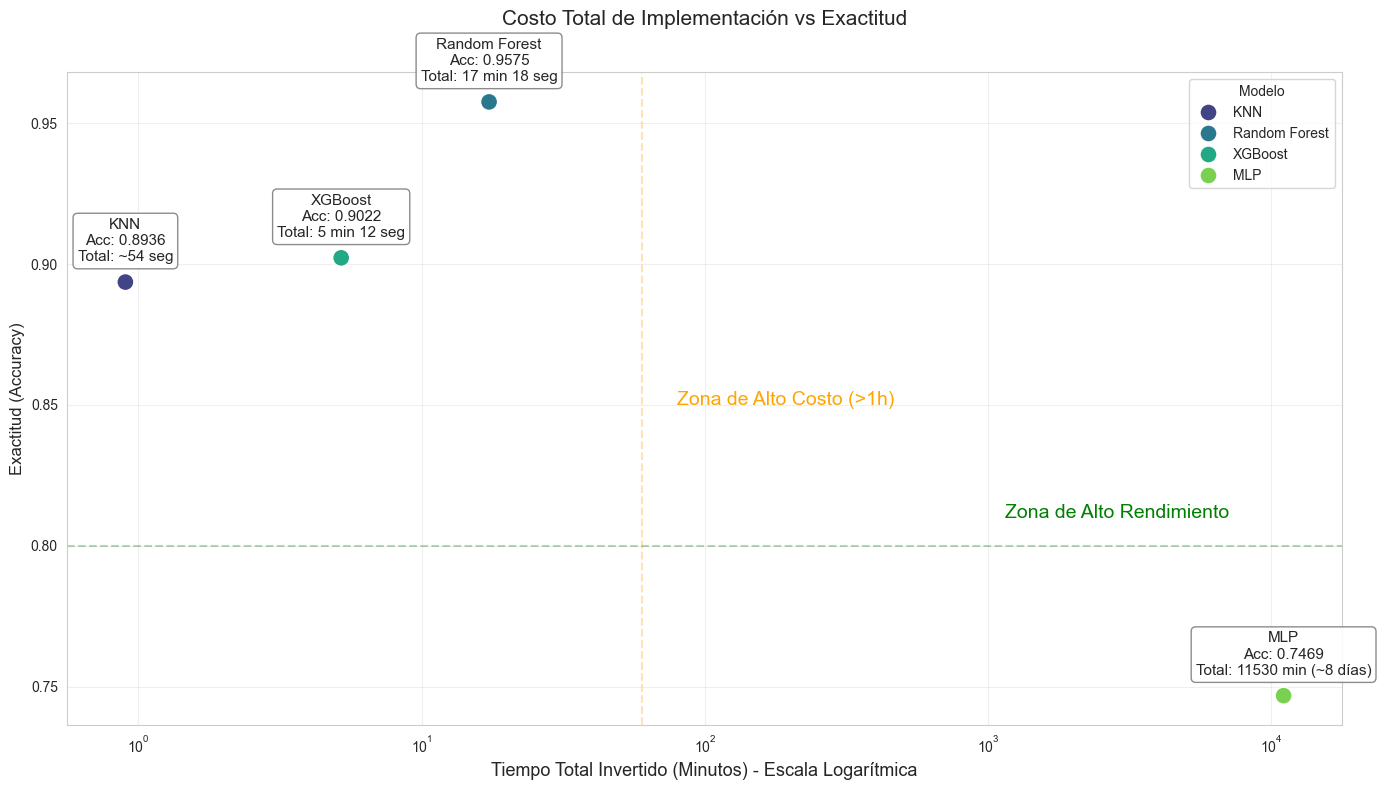

In [60]:
# Datos actualizados con tiempos de búsqueda y entrenamiento proporcionados
optimization_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.8936, 0.9575, 0.9022, 0.7469],
    'Tiempo_Busqueda_Min': [0.8, 10, 4, 8115], 
    'Tiempo_Entrenamiento_Min': [0.1, 7.3, 1.2, 2920], 
}

df_opt = pd.DataFrame(optimization_data)
df_opt['Tiempo_Total_Min'] = df_opt['Tiempo_Busqueda_Min'] + df_opt['Tiempo_Entrenamiento_Min']
df_opt['Tiempo_Total_Texto'] = [
    '~54 seg', '17 min 18 seg', '5 min 12 seg', '11530 min (~8 días)'
]

# Mostrar tabla detallada
print("Tabla de Costos Computacionales (Búsqueda + Entrenamiento Final):")
display(df_opt.style.background_gradient(subset=['Accuracy_Test'], cmap='Greens')
                   .background_gradient(subset=['Tiempo_Total_Min'], cmap='Reds'))

# Visualización: Costo Total (Búsqueda + Entrenamiento) vs Accuracy
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Scatter plot - solo círculos más pequeños
sns.scatterplot(
    data=df_opt, 
    x='Tiempo_Total_Min', 
    y='Accuracy_Test', 
    s=150, 
    hue='Modelo', 
    palette='viridis',
    zorder=5
)

# Escala logarítmica para visualizar mejor las diferencias extremas
plt.xscale('log')

# Etiquetas
plt.title('Costo Total de Implementación vs Exactitud', fontsize=15, pad=34)
plt.xlabel('Tiempo Total Invertido (Minutos) - Escala Logarítmica', fontsize=13)
plt.ylabel('Exactitud (Accuracy)', fontsize=12)

# Grilla más transparente
plt.grid(alpha=0.3)

# Anotaciones con letra más grande
for i in range(df_opt.shape[0]):
    plt.annotate(
        f"{df_opt.Modelo[i]}\nAcc: {df_opt.Accuracy_Test[i]}\nTotal: {df_opt.Tiempo_Total_Texto[i]}", 
        (df_opt.Tiempo_Total_Min[i], df_opt.Accuracy_Test[i]),
        xytext=(0, 15), textcoords='offset points', ha='center',
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

# Zona de eficiencia
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
plt.axvline(x=60, color='orange', linestyle='--', alpha=0.3) # Línea de 1 hora
# Posicionar etiquetas dentro del gráfico con letra más grande
plt.text(plt.xlim()[1] * 0.4, 0.81, 'Zona de Alto Rendimiento', color='green', ha='right', fontsize=14)
plt.text(80, 0.85, 'Zona de Alto Costo (>1h)', color='orange', ha='left', fontsize=14)

plt.tight_layout()
plt.show()